# Progetto: Previsione del Churn dei Clienti (Telco)

## Di cosa si tratta
Questo notebook analizza i dati di circa 7.000 clienti di un operatore di telecomunicazioni per esplorare **quali caratteristiche sono associate al churn** e costruire un modello che assegni un punteggio predittivo. Le associazioni e le previsioni non spiegano da sole perché una persona abbandoni il servizio.

## Obiettivo
Arrivare a un modello di machine learning che, dato un cliente, restituisca una **stima del punteggio di churn**. In uno scenario futuro e dopo adeguata validazione, il punteggio potrebbe supportare una prioritizzazione sottoposta a revisione umana; non prescrive chi contattare o quale offerta usare.

## Come è organizzato il notebook

| Fase | Cosa si fa |
|---|---|
| **0 — Setup** | Carico i dati e faccio un primo controllo di qualità |
| **1 — Analisi esplorativa** | Cerco quali caratteristiche dei clienti sono legate al churn |
| **2 — Pulizia e feature engineering** | Preparo i dati perché un modello possa usarli |
| **3 — Modellazione** | Alleno e confronto diversi modelli predittivi |
| **4 — Valutazione** | Scelgo una soglia usando uno scenario di costo ipotetico |
| **5 — Interpretazione** | Spiego cosa guida il punteggio e formulo ipotesi da validare |
| **6 — Confezionamento** | Preparo una pipeline riproducibile per l'inferenza |

Alla fine avremo un prototipo che mostra come produrre e ispezionare una tabella di punteggi; qualsiasi uso in uno scenario di retention richiederebbe validazioni e decisioni ulteriori.

Questo progetto di portfolio è stato sviluppato durante il mio percorso di formazione come Machine Learning/AI Engineer. Non documenta un deployment aziendale reale né un incarico professionale.

---


# Fase 0 — Setup del progetto

Carico i dati e faccio un primo controllo di qualità, prima dell'analisi vera e propria.

**Obiettivo di questa fase:** capire quante righe/colonne ho, se ci sono dati mancanti o duplicati, e se ci sono colonne che nella realtà non sarebbero disponibili al momento di fare la previsione (es. informazioni note solo "dopo" l'abbandono).

*Churn = tasso di abbandono dei clienti.*

In [1]:
#Importo gli strumenti che mi servono
import os

# Evita warning dipendenti dall'hardware nei confronti in cross validation.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stile grafico coerente per tutto il progetto
sns.set_theme(style="whitegrid", font_scale=1.05)

# Palette fissa: blu scuro = cliente rimasto, arancione = cliente perso (churn)
PALETTE_CHURN = {"No": "#264653", "Yes": "#E76F51"}
COLOR_NEUTRO = "#2A9D8F"
COLOR_ACCENTO = "#E9C46A"

ETICHETTE_CHURN = {"No": "Resta (No)", "Yes": "Abbandona (Yes)"}
ORDINE_CHURN = [ETICHETTE_CHURN["No"], ETICHETTE_CHURN["Yes"]]
PALETTE_CHURN = {ETICHETTE_CHURN[k]: v for k, v in PALETTE_CHURN.items()}

plt.rcParams["figure.dpi"] = 110

## Carico il dataset

Il file non è incluso nel repository. Per riprodurre l'analisi, scaricare
`Telco_customer_churn.xlsx` dal dataset pubblico IBM Telco Customer Churn su
Kaggle e collocarlo accanto al notebook, oppure impostare la variabile
d'ambiente `TELCO_CHURN_DATA`. Su Kaggle il percorso viene individuato
automaticamente tra gli input collegati al notebook. Anche il modulo
`churn_inference.py` viene caricato dal dataset tecnico collegato.

In [2]:
from pathlib import Path
import os
import sys

# Kaggle monta il modulo in un dataset di sola lettura, fuori dal percorso Python.
moduli_churn = sorted(Path("/kaggle/input").rglob("churn_inference.py"))
if len(moduli_churn) != 1:
    raise RuntimeError(
        "Atteso un solo churn_inference.py negli input Kaggle, "
        f"trovati {len(moduli_churn)}: {moduli_churn}"
    )
sys.path.insert(0, str(moduli_churn[0].parent))

from churn_inference import valida_dataset_sorgente


def individua_dataset():
    configurato = os.environ.get("TELCO_CHURN_DATA")
    candidati = []
    if configurato:
        candidati.append(Path(configurato).expanduser())
    candidati.extend([
        Path("Telco_customer_churn.xlsx"),
        Path("/kaggle/input/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx"),
    ])

    for candidato in candidati:
        if candidato.is_file():
            return candidato

    radice_kaggle = Path("/kaggle/input")
    if radice_kaggle.is_dir():
        trovati = sorted(radice_kaggle.rglob("Telco_customer_churn.xlsx"))
        if len(trovati) == 1:
            return trovati[0]
        if len(trovati) > 1:
            raise RuntimeError(
                "Più copie del dataset trovate negli input Kaggle. "
                "Impostare TELCO_CHURN_DATA sul file da usare."
            )

    raise FileNotFoundError(
        "Dataset non trovato. Collocare Telco_customer_churn.xlsx accanto "
        "al notebook oppure impostare TELCO_CHURN_DATA."
    )


percorso_dati = individua_dataset()
intestazione_originale = pd.read_excel(
    percorso_dati, header=None, nrows=1
).iloc[0].tolist()
df = pd.read_excel(percorso_dati)
valida_dataset_sorgente(
    df, intestazione_originale=intestazione_originale
)

print(f"Dataset: {percorso_dati}")
print(f"Ho caricato {df.shape[0]:,} clienti e {df.shape[1]} colonne di informazioni per ciascuno.")

Dataset: Telco_customer_churn.xlsx
Ho caricato 7,043 clienti e 33 colonne di informazioni per ciascuno.


## Primo sguardo alla struttura

Guardo le prime righe e il tipo di dato di ogni colonna, per intercettare subito eventuali stranezze (es. una colonna numerica salvata come testo).

In [3]:
# Le prime 5 righe, per farmi un'idea di come sono fatti i dati
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
# Il tipo di dato di ogni colonna
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

**Cosa noto:** quasi tutte le colonne sono testo o numeri. `Total Charges` (spesa totale) è però salvata come testo — la approfondisco più avanti.

## Valori mancanti

Conto le celle vuote per ogni colonna, per capire se il problema è serio o marginale.

In [5]:
# Conto quanti valori mancanti (celle vuote) ci sono in ogni colonna
mancanti = df.isnull().sum()
mancanti = mancanti[mancanti > 0].sort_values(ascending=False)

print("Colonne con valori mancanti:")
print(mancanti)

Colonne con valori mancanti:
Churn Reason    5174
dtype: int64


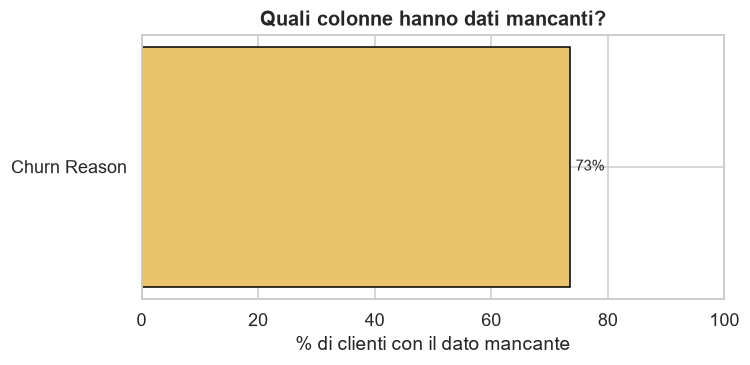

In [6]:
# GRAFICO 1 — Valori mancanti per colonna
fig, ax = plt.subplots(figsize=(7, 3.5))

perc_mancanti = (mancanti / len(df) * 100)
ax.barh(perc_mancanti.index, perc_mancanti.values, color=COLOR_ACCENTO, edgecolor="black")

for i, v in enumerate(perc_mancanti.values):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=10)

ax.set_xlabel("% di clienti con il dato mancante")
ax.set_title("Quali colonne hanno dati mancanti?", fontsize=13, weight="bold")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

**Interpretazione:** l'unica colonna con dati mancanti veri è `Churn Reason` (motivo dell'abbandono), vuota per il 73% dei clienti. Non è un errore: è vuota perché quel cliente non ha abbandonato.

## `Total Charges`: perché è salvata come testo?

Se fosse fatta solo di numeri non ci sarebbe motivo di salvarla come testo — cerco le righe "sospette".

In [7]:
# Provo a convertire ogni valore in numero: se non ci riesco, lo segno come "sospetto"
def non_e_un_numero(valore):
    try:
        float(valore)
        return False
    except (ValueError, TypeError):
        return True

righe_sospette = df[df["Total Charges"].apply(non_e_un_numero)]

print(f"Righe con 'Total Charges' non numerico: {len(righe_sospette)}")
righe_sospette[["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]]

Righe con 'Total Charges' non numerico: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,,No
2438,3115-CZMZD,0,20.25,,No
2568,5709-LVOEQ,0,80.85,,No
2667,4367-NUYAO,0,25.75,,No
2856,1371-DWPAZ,0,56.05,,No
4331,7644-OMVMY,0,19.85,,No
4687,3213-VVOLG,0,25.35,,No
5104,2520-SGTTA,0,20.00,,No
5719,2923-ARZLG,0,19.70,,No
6772,4075-WKNIU,0,73.35,,No


**Cosa ho trovato:** 11 clienti con `Tenure Months = 0` (appena arrivati). Per loro la spesa totale è semplicemente "non ancora accumulata", non un errore. La correggo in Fase 2.

## Duplicati e colonne inutili

Controllo due cose: clienti duplicati, e colonne sempre uguali per tutti (che quindi non aiutano a distinguere i clienti).

In [8]:
# 1) Clienti duplicati
duplicati = df["CustomerID"].duplicated().sum()
print(f"Clienti duplicati: {duplicati}")

# 2) Colonne con un solo valore ripetuto per tutti i clienti
colonne_costanti = [c for c in df.columns if df[c].nunique() == 1]
print(f"\nColonne sempre uguali per tutti i clienti: {colonne_costanti}")
for c in colonne_costanti:
    print(f"  - {c}: sempre '{df[c].iloc[0]}'")

Clienti duplicati: 0

Colonne sempre uguali per tutti i clienti: ['Count', 'Country', 'State']
  - Count: sempre '1'
  - Country: sempre 'United States'
  - State: sempre 'California'


**Cosa ho trovato:** nessun duplicato. Tre colonne (`Count`, `Country`, `State`) sono sempre identiche per tutti i 7.043 clienti — innocue ma inutili. Le tolgo.

## Distribuzione del churn (il nostro obiettivo)

Quanti clienti, su tutti, hanno effettivamente abbandonato? Mi dice quanto è "raro" il fenomeno da prevedere.

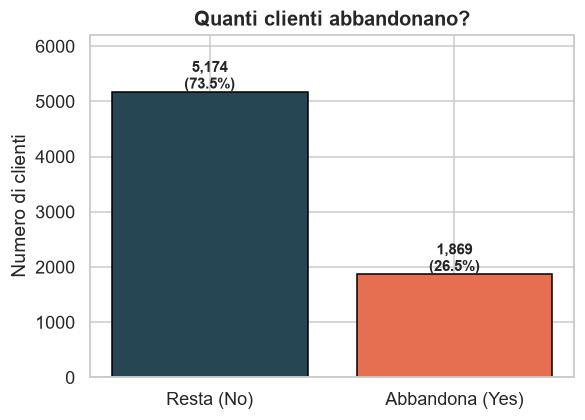

In [9]:
# GRAFICO 2 — Distribuzione del churn (quanti restano, quanti abbandonano)

conteggio = df["Churn Label"].value_counts().reindex(["No", "Yes"])
percentuali = df["Churn Label"].value_counts(normalize=True).reindex(["No", "Yes"]) * 100

fig, ax = plt.subplots(figsize=(5.5, 4))
barre = ax.bar(ORDINE_CHURN, conteggio.values,
                color=[PALETTE_CHURN[e] for e in ORDINE_CHURN],
                edgecolor="black")

for barra, valore, perc in zip(barre, conteggio.values, percentuali.values):
    altezza = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altezza + 60,
            f"{valore:,}\n({perc:.1f}%)",
            ha="center", fontsize=10, weight="bold")

ax.set_ylabel("Numero di clienti")
ax.set_title("Quanti clienti abbandonano?", fontsize=13, weight="bold")
ax.set_ylim(0, max(conteggio.values) * 1.2)
plt.tight_layout()
plt.show()

**Interpretazione:** circa 1 cliente su 4 (26.5%) ha abbandonato — un dataset **sbilanciato**. Dovrò usare metriche di valutazione adatte a questo squilibrio: la semplice "% di risposte corrette" sarebbe fuorviante (un modello che dice sempre "resta" avrebbe già il 73% di accuratezza senza aver capito nulla).

## Colonne sospette: rischio di data leakage

Alcune colonne sembrano già riassumere il comportamento futuro del cliente. Usarle per allenare il modello darebbe "la risposta del compito" in anticipo — ottime performance nel test ma inutili nella realtà, perché quelle informazioni non esistono nel momento in cui serve la previsione.

Colonne sospette: `Churn Score`, `CLTV` (valore del cliente) e `Churn Reason` (già vista sopra). Verifico confrontando chi resta e chi abbandona.

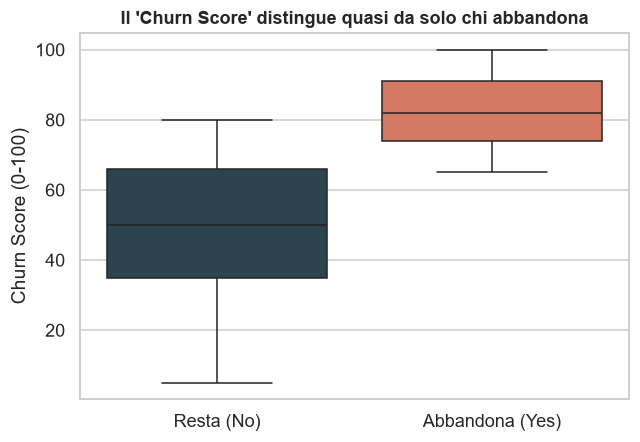

In [10]:
# GRAFICO 3 — Churn Score confrontato tra chi resta e chi abbandona

df_grafico = df.assign(Esito=df["Churn Label"].map(ETICHETTE_CHURN))

fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=df_grafico, x="Esito", y="Churn Score", order=ORDINE_CHURN,
            hue="Esito", palette=PALETTE_CHURN, legend=False, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Churn Score (0-100)")
ax.set_title("Il 'Churn Score' distingue quasi da solo chi abbandona", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

**Interpretazione:** i due gruppi sono nettamente separati (chi resta < 80, chi abbandona > 65) — segnale classico di leakage: `Churn Score` è quasi certamente calcolato da un modello che già sapeva chi avrebbe abbandonato. **Decisione: la escludo.**

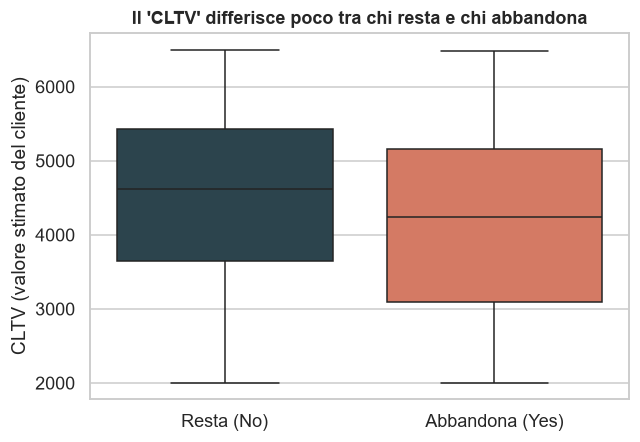

In [11]:
# GRAFICO 4 — CLTV (valore del cliente) confrontato tra chi resta e chi abbandona

fig, ax = plt.subplots(figsize=(6, 4.2))
sns.boxplot(data=df_grafico, x="Esito", y="CLTV", order=ORDINE_CHURN,
            hue="Esito", palette=PALETTE_CHURN, legend=False, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("CLTV (valore stimato del cliente)")
ax.set_title("Il 'CLTV' differisce poco tra chi resta e chi abbandona", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

**Interpretazione:** per `CLTV` la separazione tra i due gruppi è molto più debole, ma il modo in cui è calcolato non è dichiarato — non posso escludere che tenga già conto del comportamento futuro. **Decisione: la escludo comunque, per prudenza.**

Su `Churn Reason` non serve un grafico: è vuota esattamente per chi non ha abbandonato — è il caso di leakage più netto. **La escludo.**

## Colonne geografiche: troppo "rumore", poco segnale

`City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` non sono un rischio di leakage, ma hanno troppe etichette diverse (quasi un valore per cliente): un modello fa fatica a impararci qualcosa e rischia di "memorizzare" invece di generalizzare. Guardo quante etichette diverse contiene ogni colonna.

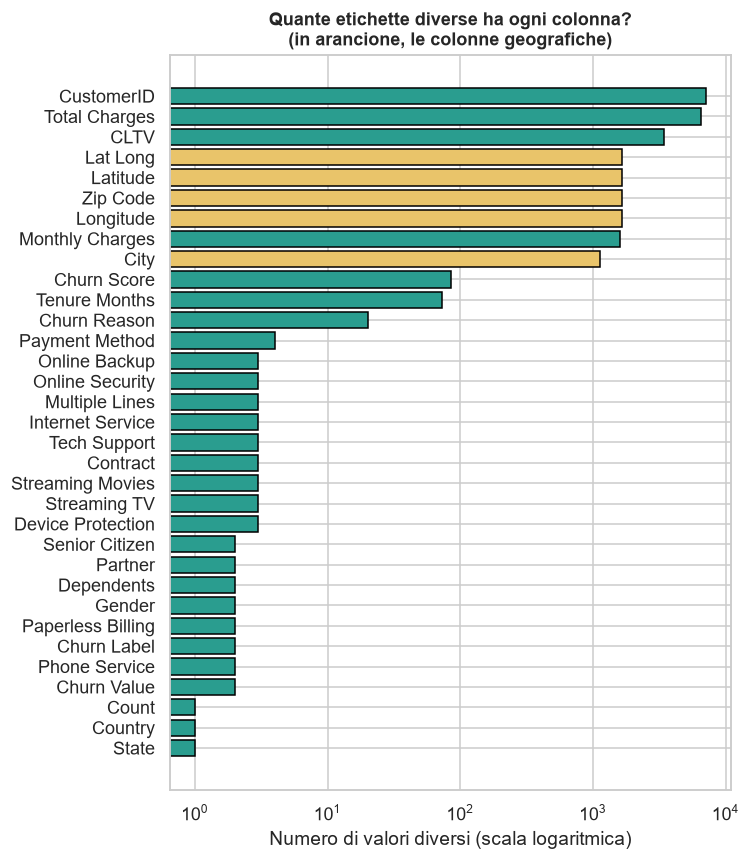

In [12]:
# GRAFICO 5 — Quante etichette diverse contiene ogni colonna(cardinalità)
cardinalità = df.nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
colori_barre = [COLOR_ACCENTO if col in ["City", "Zip Code", "Lat Long", "Latitude", "Longitude"]
                else COLOR_NEUTRO for col in cardinalità.index]

ax.barh(cardinalità.index[::-1], cardinalità.values[::-1], color=colori_barre[::-1], edgecolor="black")
ax.set_xlabel("Numero di valori diversi (scala logaritmica)")
ax.set_xscale("log")
ax.set_title("Quante etichette diverse ha ogni colonna?\n(in arancione, le colonne geografiche)",
             fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

**Interpretazione:** le colonne geografiche sono tra quelle con più etichette in assoluto (`City` oltre 1.100, le coordinate oltre 1.600).

**Decisione:** le escludo in questa prima versione del modello, per restare semplici. Un'eventuale versione geografica più "grezza" (es. raggruppata per area) è materiale per un'iterazione futura.

## Riepilogo: da 33 a 19 colonne

Ricapitolo quali colonne porto avanti in Fase 1 e quali escludo.

In [13]:
colonne_escluse = {
    "CustomerID": "identificativo, nessun valore predittivo",
    "Count": "sempre uguale a 1 per tutti",
    "Country": "sempre 'United States' per tutti",
    "State": "sempre 'California' per tutti",
    "City": "troppe categorie diverse (oltre 1.100)",
    "Zip Code": "troppe categorie diverse",
    "Lat Long": "troppe categorie diverse",
    "Latitude": "troppe categorie diverse",
    "Longitude": "troppe categorie diverse",
    "Churn Value": "è lo stesso identico obiettivo, solo in formato numero",
    "Churn Score": "fuga di informazioni: già quasi coincidente con il risultato",
    "CLTV": "possibile fuga di informazioni, formula di calcolo non trasparente",
    "Churn Reason": "fuga di informazioni: esiste solo per chi ha già abbandonato",
}

colonne_mantenute = [c for c in df.columns if c not in colonne_escluse and c != "Churn Label"]

print(f"Colonne totali di partenza: {df.shape[1]}")
print(f"Colonne escluse: {len(colonne_escluse)}")
print(f"Colonne mantenute (+ target 'Churn Label'): {len(colonne_mantenute)} + 1")
print()
print("Colonne che porto avanti in Fase 1:")
for c in colonne_mantenute:
    print(f"  - {c}")

Colonne totali di partenza: 33
Colonne escluse: 13
Colonne mantenute (+ target 'Churn Label'): 19 + 1

Colonne che porto avanti in Fase 1:
  - Gender
  - Senior Citizen
  - Partner
  - Dependents
  - Tenure Months
  - Phone Service
  - Multiple Lines
  - Internet Service
  - Online Security
  - Online Backup
  - Device Protection
  - Tech Support
  - Streaming TV
  - Streaming Movies
  - Contract
  - Paperless Billing
  - Payment Method
  - Monthly Charges
  - Total Charges


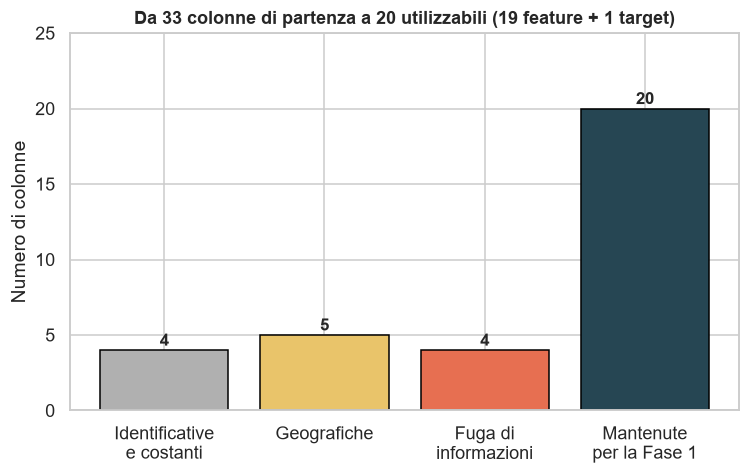

In [14]:
# GRAFICO 6 — Riepilogo visivo: quante colonne tengo, quante scarto, e perché
fig, ax = plt.subplots(figsize=(7, 4.5))

categorie = ["Identificative\ne costanti", "Geografiche\n",
             "Fuga di\ninformazioni", "Mantenute\nper la Fase 1"]
conteggi = [4, 5, 4, len(colonne_mantenute) + 1]  # +1 per includere il target mantenuto
colori = ["#B0B0B0", COLOR_ACCENTO, "#E76F51", "#264653"]

barre = ax.bar(categorie, conteggi, color=colori, edgecolor="black")
for barra, valore in zip(barre, conteggi):
    ax.text(barra.get_x() + barra.get_width()/2, valore + 0.3, str(valore),
            ha="center", fontsize=11, weight="bold")

ax.set_ylabel("Numero di colonne")
ax.set_title("Da 33 colonne di partenza a 20 utilizzabili (19 feature + 1 target)",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(conteggi) * 1.25)
plt.tight_layout()
plt.show()

## Sintesi Fase 0

Ho aperto il file con ~7.000 clienti e fatto un primo controllo di qualità. Risultati:

- Dati quasi tutti completi. L'unico "buco" importante (`Churn Reason`) è normale, non un errore.
- 11 clienti nuovissimi non hanno ancora una spesa totale registrata — la sistemo in Fase 2.
- Circa 1 cliente su 4 ha abbandonato: dataset sbilanciato, da tenere in conto nella valutazione.
- 3 colonne "spiano il futuro" (`Churn Score`, `CLTV`, `Churn Reason`) → escluse.
- Colonne geografiche troppo dettagliate → escluse.

**Risultato:** da 33 colonne di partenza ne porto avanti 19, più il target (l'abbandono).

---
# Fase 1 — Analisi esplorativa (EDA)

**Domanda di questa fase: quali caratteristiche sono associate al churn nel campione?**

Guardo la relazione tra il churn e: tipo di **contratto**, **anzianità** del cliente, tipo di **connessione internet**, **metodo di pagamento**, **numero di servizi attivi**, **spesa**.

(La distribuzione generale del target, 26.5% di churn, è già stata mostrata in Fase 0.)

## Preparazione dati per l'EDA

Riduco `df` alle 19 colonne decise in Fase 0 e aggiungo una colonna di appoggio `Esito` (etichette leggibili per i grafici).

In [15]:
# Riduco df alle sole colonne che ho deciso di mantenere in Fase 0
df = df.drop(columns=list(colonne_escluse.keys()))

# 'Total Charges' era salvata come testo per via degli 11 clienti a tenure=0.
# La converto in numero: i buchi restano NaN e verranno esclusi dai grafici.
# La correzione vera (impostare a 0) la faccio in Fase 2.
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Colonna di appoggio per le legende dei grafici (non è una feature)
df["Esito"] = df["Churn Label"].map(ETICHETTE_CHURN)

print(f"Righe: {df.shape[0]:,}  |  Colonne effettive (feature+target): {df.shape[1] - 1}")
print(f"NaN in 'Total Charges': {df['Total Charges'].isna().sum()}  (attesi 11)")

Righe: 7,043  |  Colonne effettive (feature+target): 20
NaN in 'Total Charges': 11  (attesi 11)


## Il tipo di contratto

Dice se il cliente è vincolato per un periodo lungo o può andarsene ogni mese. Guardo il **tasso di churn** dentro ogni tipo di contratto (non i valori assoluti).

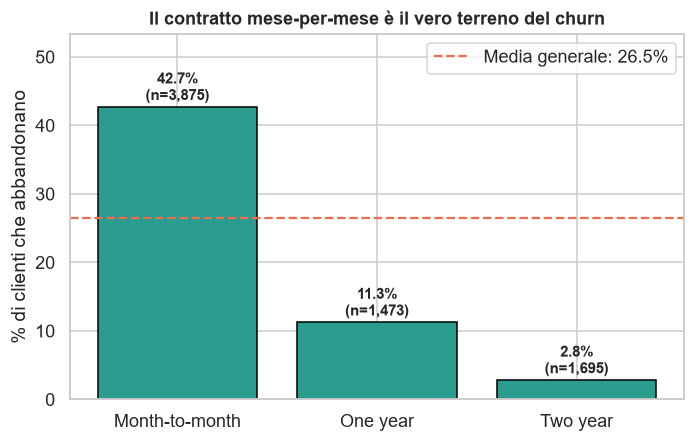

In [16]:
# GRAFICO 7 — Tasso di churn per tipo di contratto

ordine_contratto = ["Month-to-month", "One year", "Two year"]

tasso_contratto = (df.groupby("Contract")["Churn Label"]
                     .apply(lambda s: (s == "Yes").mean() * 100)
                     .reindex(ordine_contratto))
n_contratto = df["Contract"].value_counts().reindex(ordine_contratto)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
barre = ax.bar(ordine_contratto, tasso_contratto.values,
               color=COLOR_NEUTRO, edgecolor="black")

for barra, tasso, n in zip(barre, tasso_contratto.values, n_contratto.values):
    ax.text(barra.get_x() + barra.get_width()/2, tasso + 1,
            f"{tasso:.1f}%\n(n={n:,})", ha="center", fontsize=10, weight="bold")

tasso_medio = (df["Churn Label"] == "Yes").mean() * 100
ax.axhline(tasso_medio, color="#E76F51", linestyle="--", linewidth=1.5,
           label=f"Media generale: {tasso_medio:.1f}%")

ax.set_ylabel("% di clienti che abbandonano")
ax.set_title("Il contratto mese-per-mese è il vero terreno del churn",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(tasso_contratto.values) * 1.25)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Interpretazione descrittiva:** **mese-per-mese** → ~43% di churn (più del doppio della media), **annuale** → ~11%, **biennale** → ~3%. Il tipo di contratto mostra una delle associazioni più forti del campione, ma questa tabella non dimostra che il vincolo contrattuale causi la differenza.

La maggior parte dei clienti (n=3.875) è sul mensile, quindi molte osservazioni di churn appartengono a quel gruppo. L'eventuale effetto di un cambio di contratto sulla retention richiederebbe una valutazione causale o sperimentale.

## L'anzianità (Tenure)

`Tenure Months` = mesi da cui il cliente è con noi. La guardo in due modi: come si distribuiscono i due gruppi lungo l'anzianità, e come cambia il tasso di churn al crescere dell'anzianità.

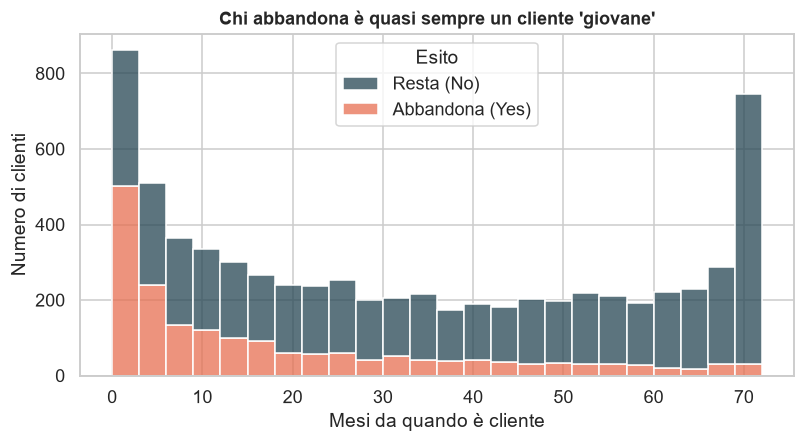

In [17]:
# GRAFICO 8 — Distribuzione dell'anzianità per chi resta e per chi abbandona

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.histplot(data=df, x="Tenure Months", hue="Esito",
             hue_order=ORDINE_CHURN, palette=PALETTE_CHURN,
             bins=24, multiple="stack", edgecolor="white", ax=ax)

ax.set_xlabel("Mesi da quando è cliente")
ax.set_ylabel("Numero di clienti")
ax.set_title("Chi abbandona è quasi sempre un cliente 'giovane'",
             fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

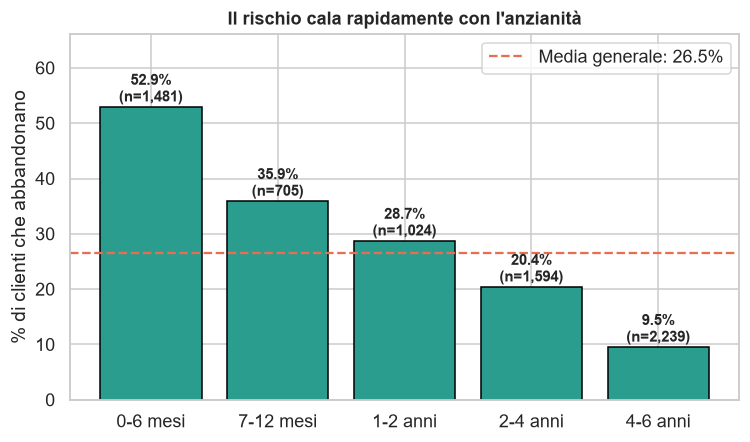

In [18]:
# GRAFICO 9 — Tasso di churn per fascia di anzianità

fasce_tenure = pd.cut(df["Tenure Months"],
                      bins=[-0.1, 6, 12, 24, 48, 72],
                      labels=["0-6 mesi", "7-12 mesi", "1-2 anni", "2-4 anni", "4-6 anni"])

tasso_tenure = (df.assign(fascia=fasce_tenure)
                  .groupby("fascia", observed=True)["Churn Label"]
                  .apply(lambda s: (s == "Yes").mean() * 100))
n_tenure = fasce_tenure.value_counts().reindex(tasso_tenure.index)

fig, ax = plt.subplots(figsize=(7, 4.2))
barre = ax.bar(tasso_tenure.index.astype(str), tasso_tenure.values,
               color=COLOR_NEUTRO, edgecolor="black")

for barra, tasso, n in zip(barre, tasso_tenure.values, n_tenure.values):
    ax.text(barra.get_x() + barra.get_width()/2, tasso + 1,
            f"{tasso:.1f}%\n(n={n:,})", ha="center", fontsize=10, weight="bold")

tasso_medio = (df["Churn Label"] == "Yes").mean() * 100
ax.axhline(tasso_medio, color="#E76F51", linestyle="--", linewidth=1.5,
           label=f"Media generale: {tasso_medio:.1f}%")

ax.set_ylabel("% di clienti che abbandonano")
ax.set_title("Il rischio cala rapidamente con l'anzianità",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(tasso_tenure.values) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretazione descrittiva:** **primi 6 mesi**: oltre 1 cliente su 2 abbandona (~53%). Il tasso di churn osservato scende poi a ~36% (7-12 mesi), ~29% (1-2 anni) e ~10% (oltre 4 anni).

I primi 6-12 mesi costituiscono quindi un segmento da approfondire. I dati non dimostrano che intervenire in quella finestra riduca il churn né che la sola permanenza causi una maggiore retention.

## Il tipo di connessione internet

Tre tipi: **DSL** (più vecchia/lenta), **fibra ottica** (più veloce, più costosa), **nessun internet** (solo telefono).

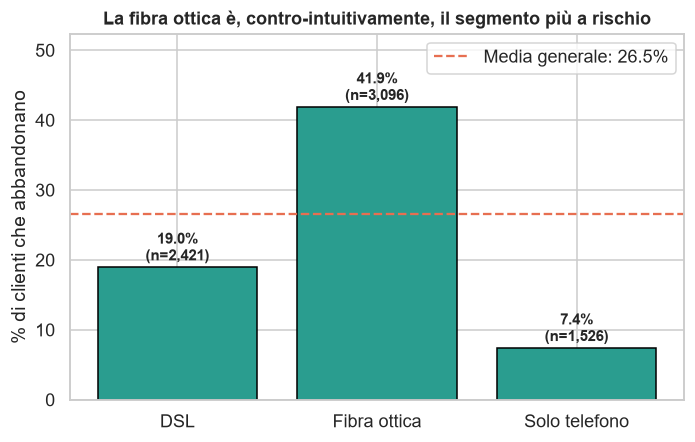

In [19]:
# GRAFICO 10 — Tasso di churn per tipo di connessione internet

ordine_internet = ["DSL", "Fiber optic", "No"]
etichette_internet = {"DSL": "DSL", "Fiber optic": "Fibra ottica", "No": "Solo telefono"}

tasso_internet = (df.groupby("Internet Service")["Churn Label"]
                    .apply(lambda s: (s == "Yes").mean() * 100)
                    .reindex(ordine_internet))
n_internet = df["Internet Service"].value_counts().reindex(ordine_internet)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
barre = ax.bar([etichette_internet[i] for i in ordine_internet],
               tasso_internet.values, color=COLOR_NEUTRO, edgecolor="black")

for barra, tasso, n in zip(barre, tasso_internet.values, n_internet.values):
    ax.text(barra.get_x() + barra.get_width()/2, tasso + 1,
            f"{tasso:.1f}%\n(n={n:,})", ha="center", fontsize=10, weight="bold")

tasso_medio = (df["Churn Label"] == "Yes").mean() * 100
ax.axhline(tasso_medio, color="#E76F51", linestyle="--", linewidth=1.5,
           label=f"Media generale: {tasso_medio:.1f}%")

ax.set_ylabel("% di clienti che abbandonano")
ax.set_title("La fibra ottica è, contro-intuitivamente, il segmento più a rischio",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(tasso_internet.values) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

Interpretazione: risultato controintuitivo. Chi non ha internet abbandona pochissimo (7%), il DSL è in linea con la media (19%), ma la fibra ottica — il servizio "premium" — abbandona nel 42% dei casi.

Nel campione, la fibra è associata sia a maggiore churn sia a maggiore spesa. Il confronto sui costi nella sezione 1.7 descrive questa associazione, ma non verifica il meccanismo che produce il churn: non misura aspettative, qualità percepita o disponibilità a cambiare operatore. Il segmento fibra merita quindi un'analisi successiva, non un'azione automatica; per distinguere cause e semplici correlazioni servono dati aggiuntivi e una valutazione causale o sperimentale.

## Il metodo di pagamento

4 metodi, divisi in **automatici** (conto/carta) e **manuali** (assegno cartaceo o elettronico). Ipotesi descrittiva da verificare: i gruppi potrebbero mostrare tassi di churn diversi.

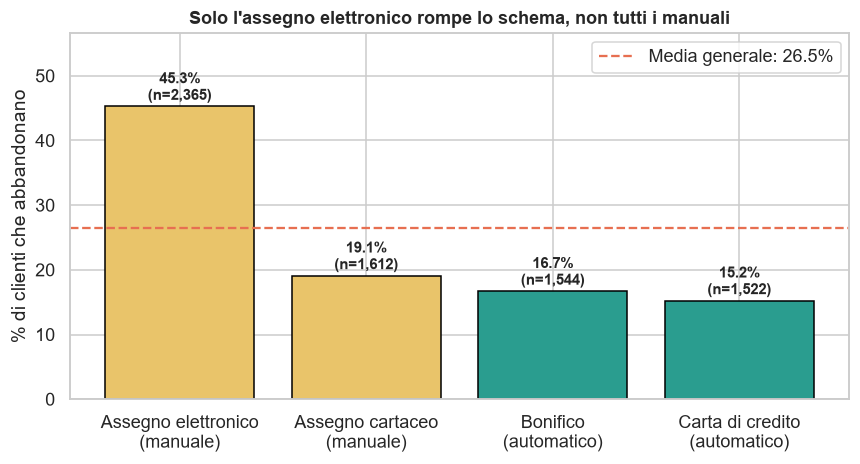

In [20]:
# GRAFICO 11 — Tasso di churn per metodo di pagamento

ordine_pagamento = ["Electronic check", "Mailed check",
                    "Bank transfer (automatic)", "Credit card (automatic)"]
etichette_pagamento = {
    "Electronic check":          "Assegno elettronico\n(manuale)",
    "Mailed check":              "Assegno cartaceo\n(manuale)",
    "Bank transfer (automatic)": "Bonifico\n(automatico)",
    "Credit card (automatic)":   "Carta di credito\n(automatico)",
}

tasso_pag = (df.groupby("Payment Method")["Churn Label"]
               .apply(lambda s: (s == "Yes").mean() * 100)
               .reindex(ordine_pagamento))
n_pag = df["Payment Method"].value_counts().reindex(ordine_pagamento)

# Coloro in giallo i manuali, in verde gli automatici, per rendere visivo il pattern
colori_pag = [COLOR_ACCENTO, COLOR_ACCENTO, COLOR_NEUTRO, COLOR_NEUTRO]

fig, ax = plt.subplots(figsize=(8, 4.4))
barre = ax.bar([etichette_pagamento[m] for m in ordine_pagamento],
               tasso_pag.values, color=colori_pag, edgecolor="black")

for barra, tasso, n in zip(barre, tasso_pag.values, n_pag.values):
    ax.text(barra.get_x() + barra.get_width()/2, tasso + 1,
            f"{tasso:.1f}%\n(n={n:,})", ha="center", fontsize=10, weight="bold")

tasso_medio = (df["Churn Label"] == "Yes").mean() * 100
ax.axhline(tasso_medio, color="#E76F51", linestyle="--", linewidth=1.5,
           label=f"Media generale: {tasso_medio:.1f}%")

ax.set_ylabel("% di clienti che abbandonano")
ax.set_title("Solo l'assegno elettronico rompe lo schema, non tutti i manuali",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(tasso_pag.values) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

Interpretazione: il pattern non è "manuale vs automatico" come atteso. Bonifico (17%), carta (15%) e assegno cartaceo (19%) sono tutti sotto la media. A rompere lo schema è l'assegno elettronico, al 45% — quasi il triplo degli altri.

L'assegno elettronico identifica un gruppo numeroso (n=2.365) con churn osservato al 45%, probabilmente sovrapposto ai segmenti fibra e contratto mensile. È un'associazione descrittiva da approfondire: non dimostra una causa e non definisce una lista di contatti.

## Il numero di servizi attivi

Considero 7 servizi opzionali (sicurezza online, backup, protezione device, supporto tecnico, streaming TV/film, linee multiple). Per l'EDA verifico come varia il churn osservato al variare del conteggio; il numero di servizi non misura da solo fedeltà o effetto di un'offerta.

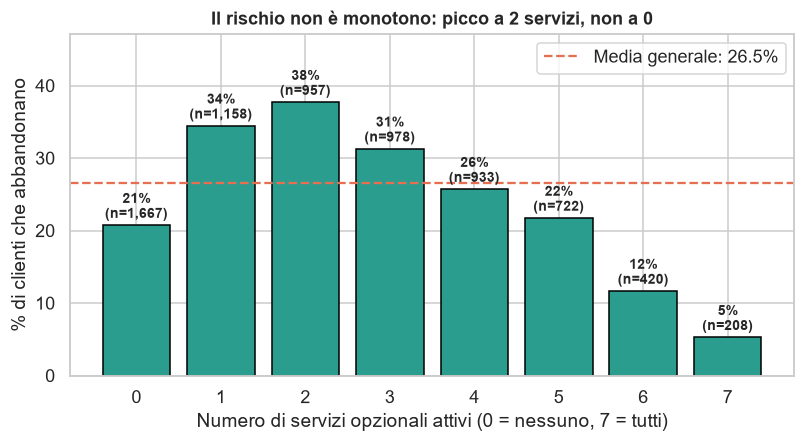

In [21]:
# Conteggio *provvisorio* dei servizi attivi (solo per esplorare qui, non lo salvo nel df definitivo)
servizi_opzionali = [
    "Online Security", "Online Backup", "Device Protection", "Tech Support",
    "Streaming TV", "Streaming Movies", "Multiple Lines",
]
n_servizi_eda = (df[servizi_opzionali] == "Yes").sum(axis=1)

# GRAFICO 12 — Tasso di churn per numero di servizi opzionali attivi
tasso_serv = (pd.DataFrame({"n_servizi": n_servizi_eda, "churn": df["Churn Label"]})
                .groupby("n_servizi")["churn"]
                .apply(lambda s: (s == "Yes").mean() * 100))
n_serv = n_servizi_eda.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
barre = ax.bar(tasso_serv.index.astype(str), tasso_serv.values,
               color=COLOR_NEUTRO, edgecolor="black")

for barra, tasso, n in zip(barre, tasso_serv.values, n_serv.values):
    ax.text(barra.get_x() + barra.get_width()/2, tasso + 1,
            f"{tasso:.0f}%\n(n={n:,})", ha="center", fontsize=9, weight="bold")

tasso_medio = (df["Churn Label"] == "Yes").mean() * 100
ax.axhline(tasso_medio, color="#E76F51", linestyle="--", linewidth=1.5,
           label=f"Media generale: {tasso_medio:.1f}%")

ax.set_xlabel("Numero di servizi opzionali attivi (0 = nessuno, 7 = tutti)")
ax.set_ylabel("% di clienti che abbandonano")
ax.set_title("Il rischio non è monotono: picco a 2 servizi, non a 0",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(tasso_serv.values) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

Interpretazione: la relazione non è monotona. Il churn parte da 21% con 0 servizi, sale al picco del 38% con 2 servizi, poi scende fino al 5% con tutti e 7.

Nel campione, chi ha 0 servizi è per lo più nel segmento "solo telefono", con churn osservato al 7%; chi ha 1-3 servizi appartiene spesso al segmento fibra. Da 4 servizi in su il tasso osservato diminuisce, ma il conteggio dei servizi può essere associato ad altre caratteristiche e non dimostra un effetto causale sulla retention.

Queste associazioni suggeriscono segmenti da analizzare. Non permettono di concludere che il cross-selling migliori la retention o che una specifica combinazione richieda automaticamente un intervento.

## La spesa

Guardo la spesa mensile (`Monthly Charges`) e come si combina con l'anzianità. (`Total Charges` è ridondante rispetto a `Monthly Charges × Tenure` e ha gli 11 buchi noti — la lascio da parte qui.)

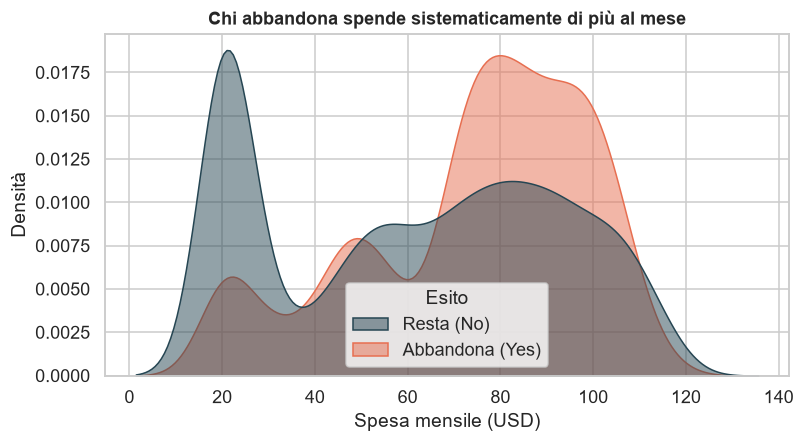

In [22]:
# GRAFICO 13 — Distribuzione della spesa mensile per chi resta e per chi abbandona

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.kdeplot(data=df, x="Monthly Charges", hue="Esito",
            hue_order=ORDINE_CHURN, palette=PALETTE_CHURN,
            fill=True, alpha=0.5, common_norm=False, ax=ax)

ax.set_xlabel("Spesa mensile (USD)")
ax.set_ylabel("Densità")
ax.set_title("Chi abbandona spende sistematicamente di più al mese",
             fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

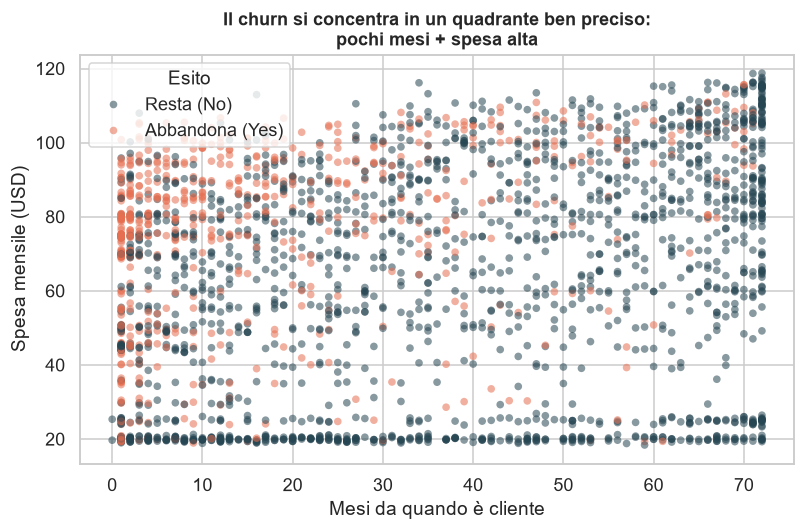

In [23]:
# GRAFICO 14 — Anzianità × Spesa mensile, colorato per esito

fig, ax = plt.subplots(figsize=(7.5, 5))
# Campiono per non appesantire il grafico (7.000 punti sarebbero un macchione)
df_plot = df.sample(2500, random_state=42)

sns.scatterplot(data=df_plot, x="Tenure Months", y="Monthly Charges",
                hue="Esito", hue_order=ORDINE_CHURN, palette=PALETTE_CHURN,
                alpha=0.55, s=25, edgecolor="none", ax=ax)

ax.set_xlabel("Mesi da quando è cliente")
ax.set_ylabel("Spesa mensile (USD)")
ax.set_title("Il churn si concentra in un quadrante ben preciso:\npochi mesi + spesa alta",
             fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

**Interpretazione:** chi abbandona spende chiaramente di più. Chi resta ha un picco intorno a 20 USD/mese (clienti "solo telefono") e un secondo gruppo più in alto; chi abbandona è raro sotto 40 USD e si concentra tra 70-100 USD (fibra + servizi).

Nel campione, molte osservazioni di churn si concentrano nell'area "pochi mesi + spesa alta". La combinazione è descrittiva: non stabilisce perché quei clienti abbandonino né misura la loro fedeltà.

*Profilo descrittivo da verificare:* meno di 12 mesi, spesa sopra 80 USD, contratto mensile, assegno elettronico. In Fase 3 verifico se questa combinazione aggiunge informazione predittiva sul medesimo campione; non la tratto come segmento operativo già validato.

## Variabili anagrafiche

Controllo rapido su `Gender`, `Senior Citizen`, `Partner`, `Dependents` per decidere se meritano di entrare nel modello.

In [24]:
# Tassi di churn per le 4 variabili anagrafiche
media = (df["Churn Label"] == "Yes").mean() * 100

for col in ["Gender", "Senior Citizen", "Partner", "Dependents"]:
    tasso = df.groupby(col)["Churn Label"].apply(lambda s: (s == "Yes").mean() * 100)
    n = df[col].value_counts()
    print(f"\n{col}:")
    for k in tasso.index:
        delta = tasso[k] - media
        print(f"  {k:6}  churn={tasso[k]:5.1f}%   n={n[k]:>4}   Δ vs media = {delta:+5.1f} pp")


Gender:
  Female  churn= 26.9%   n=3488   Δ vs media =  +0.4 pp
  Male    churn= 26.2%   n=3555   Δ vs media =  -0.4 pp

Senior Citizen:
  No      churn= 23.6%   n=5901   Δ vs media =  -2.9 pp
  Yes     churn= 41.7%   n=1142   Δ vs media = +15.1 pp

Partner:
  No      churn= 33.0%   n=3641   Δ vs media =  +6.4 pp
  Yes     churn= 19.7%   n=3402   Δ vs media =  -6.9 pp

Dependents:
  No      churn= 32.6%   n=5416   Δ vs media =  +6.0 pp
  Yes     churn=  6.5%   n=1627   Δ vs media = -20.0 pp


**Interpretazione:**
- **Gender** → effetto nullo (Δ 0.7 pp). **Escludo in Fase 2.**
- **Senior Citizen** → differenza osservata di 18 pp (41.7% di churn), presente anche stratificando per contratto. **Tengo**, senza interpretarla come effetto causale.
- **Partner** → Δ 13 pp, ma chi ha partner ha in media più anzianità (42 vs 23 mesi): il segnale è probabilmente già catturato da `Tenure Months`. **Tengo per prudenza**, verifico in Fase 5.
- **Dependents** → differenza osservata di 26 pp (6.5% di churn per chi ha familiari a carico). **Tengo**, con i limiti di fairness e proxy discussi in Fase 5.

## Sintesi Fase 1 — associazioni osservate nel campione

**Caratteristiche dei gruppi con churn osservato sopra la media:**
- contratto **mese-per-mese** (~43% vs ~3% del biennale)
- meno di 12 mesi di anzianità, specie i primi 6 (~53%)
- abbonato alla **fibra ottica** (~42%)
- paga con **assegno elettronico** (~45%)
- 1-3 servizi opzionali attivi (picco ~38% con 2)
- **spesa mensile alta**, tipicamente sopra 70 USD
- tasso osservato più alto tra anziani e clienti senza persone a carico

Queste variabili si sovrappongono spesso sullo stesso cliente. Nelle Fasi 3-4 verifico quale informazione predittiva aggiungono sul medesimo campione, senza interpretarla come effetto causale.

**Cosa porto in Fase 2:** sistemare gli 11 `Total Charges` mancanti; rimuovere `Gender`; codificare le categoriche (collassando gli stati ridondanti); costruire bene la feature "numero di servizi attivi"; valutare feature composte (spesa/anzianità, flag "profilo a rischio"); fare lo split train/test **prima** di encoding e scaling.

# Fase 2 — Pulizia dati e Feature Engineering

Preparo i dati perché un modello possa leggerli: valori mancanti sistemati, categoriche codificate, feature nuove con senso di business.

**Passi:** 1) pulizia e feature engineering, 2) split train/test, 3) scaling ed encoding appresi solo dal training set.

C'è però una scelta di metodo che viene prima di tutti e tre, e che condiziona anche la Fase 6: **il preprocessing non lo scrivo dentro il notebook, lo scrivo in un modulo esterno e da lì lo importo**. Il motivo è che gli stessi passaggi devono restare identici tra addestramento e inferenza del prototipo, anche su clienti che il modello non ha mai visto. Se li scrivessi due volte — una qui a mano e una nel modulo di inferenza — avrei due implementazioni della stessa cosa, che col tempo potrebbero divergere: basta correggere un dettaglio in un posto e dimenticarlo nell'altro, e il modello riceverebbe dati diversi da quelli su cui è stato addestrato. È un errore silenzioso e difficile da trovare, perché il modello continua a rispondere senza segnalare niente.

Il modulo è `churn_inference.py`, nella stessa cartella. Da qui in avanti il notebook lo usa come unica fonte del preprocessing.

Alla fine: `X_train`, `X_test`, `y_train`, `y_test` pronti per la Fase 3.

## Pulizia e feature engineering: `ChurnFeatureEngineer`

Il primo blocco del modulo raccoglie tutti i passaggi che si applicano a un cliente per volta:

**Pulizia**
- **`Total Charges`**: gli 11 clienti con `Tenure Months = 0` non hanno ancora ricevuto la prima fattura → imposto a `0.0`. Non è un dato mancante, è "spesa non ancora accumulata".
- **7 categoriche a 3 stati**: `"No phone service"` e `"No internet service"` equivalgono a `"No"` — l'informazione "ha telefono/internet" è già in `Phone Service` e `Internet Service`. Collassandole a 2 stati ottengo meno colonne dopo l'encoding e un modello più snello.

**Tre feature nuove, motivate dalla Fase 1**
- **`Num Services Optional`** — conteggio dei 7 servizi opzionali attivi. In Fase 1 la relazione col churn non era monotona (picco al centro): insieme a `Internet Service` il modello può ricostruire quel pattern.
- **`Charge Per Tenure`** = `Monthly Charges / (Tenure Months + 1)`. Riassume il quadrante di rischio "pochi mesi + spesa alta" visto in Fase 1.
- **`Profilo Rischio`** — flag 1 quando **tutte e tre** sono vere: contratto mensile, fibra, pagamento con assegno elettronico. Cattura un'interazione a tre che una logistica lineare non vedrebbe da sola.

Nessuno di questi passaggi guarda gli altri clienti: il risultato per una riga dipende solo da quella riga. È il motivo per cui posso applicarli prima dello split senza creare leakage — cosa che invece non vale per scaler ed encoder, che imparano statistiche dall'insieme dei dati e vanno quindi addestrati solo sul train.

Fuori restano due colonne: **`Gender`** (nessun segnale in Fase 1) e **`Esito`** (colonna di appoggio per i grafici, non una feature).

In [25]:
from churn_inference import (
    ChurnFeatureEngineer,
    COLONNE_RAW_INPUT,
    COLONNE_DA_COLLASSARE,
)

# Le due colonne che non sono feature
df = df.drop(columns=["Gender", "Esito"])

# Stato "prima", per poter verificare che cosa cambia davvero
nan_prima = int(df["Total Charges"].isna().sum())
stati_prima = df["Online Security"].value_counts().to_dict()

# Un'unica chiamata applica pulizia e feature engineering
df_fe = ChurnFeatureEngineer().fit_transform(df)

print(f"Total Charges — NaN prima: {nan_prima}, dopo: {df_fe['Total Charges'].isna().sum()}")
print(f"  (gli {nan_prima} clienti a tenure 0 ora hanno spesa totale 0.0)")

print(f"\nOnline Security — prima: {stati_prima}")
print(f"                  dopo : {df_fe['Online Security'].value_counts().to_dict()}")
stati = {c: sorted(df_fe[c].unique().tolist()) for c in COLONNE_DA_COLLASSARE}
print(f"  tutte e {len(stati)} le colonne semplificate hanno 2 stati: "
      f"{all(s == ['No', 'Yes'] for s in stati.values())}")

print("\nNum Services Optional — distribuzione:")
print(df_fe["Num Services Optional"].value_counts().sort_index().to_string())

print(f"\nCharge Per Tenure — range {df_fe['Charge Per Tenure'].min():.2f} → "
      f"{df_fe['Charge Per Tenure'].max():.2f}, mediana {df_fe['Charge Per Tenure'].median():.2f}")

n_rischio = int(df_fe["Profilo Rischio"].sum())
churn_rischio = (df_fe.loc[df_fe["Profilo Rischio"] == 1, "Churn Label"] == "Yes").mean() * 100
churn_altri = (df_fe.loc[df_fe["Profilo Rischio"] == 0, "Churn Label"] == "Yes").mean() * 100
print(f"\nProfilo Rischio = 1: {n_rischio:,} clienti ({n_rischio / len(df_fe) * 100:.1f}% del totale)")
print(f"  tasso di churn nel gruppo a rischio: {churn_rischio:.1f}%")
print(f"  tasso di churn nel resto della base: {churn_altri:.1f}%")

Total Charges — NaN prima: 11, dopo: 0
  (gli 11 clienti a tenure 0 ora hanno spesa totale 0.0)

Online Security — prima: {'No': 3498, 'Yes': 2019, 'No internet service': 1526}
                  dopo : {'No': 5024, 'Yes': 2019}
  tutte e 7 le colonne semplificate hanno 2 stati: True

Num Services Optional — distribuzione:
Num Services Optional
0    1667
1    1158
2     957
3     978
4     933
5     722
6     420
7     208

Charge Per Tenure — range 0.26 → 80.85, mediana 2.08

Profilo Rischio = 1: 1,307 clienti (18.6% del totale)
  tasso di churn nel gruppo a rischio: 60.4%
  tasso di churn nel resto della base: 18.8%


**Verifica di sanità:** il flag `Profilo Rischio` isola il 18.6% della base, con il 60.4% di churn al suo interno contro il 18.8% nel resto — più del triplo. Nel campione è quindi un segmento descrittivo ad alto rischio; non costituisce una lista operativa e richiede validazione esterna o temporale e revisione umana prima di qualunque utilizzo.

## Split train/test — prima di scaling e encoding

Regola generale: tutto ciò che impara statistiche dall'insieme dei dati (medie dello scaler, elenco delle categorie dell'encoder) va appreso **solo sul train**, altrimenti il test set contribuisce indirettamente all'addestramento e le performance risultano gonfiate.

Un dettaglio che conta per la Fase 6: come `X` prendo le **18 colonne grezze** del catalogo, non quelle già ripulite. È la forma prevista per una possibile estrazione mensile — `Total Charges` compresa, con i suoi buchi. Così la pipeline che addestro è la stessa usata nelle prove di inferenza del prototipo, e non una che presuppone una pulizia fatta da qualcun altro.

**Split stratificato 80/20**: la proporzione di churn resta identica (26.5%) in train e test.

In [26]:
from sklearn.model_selection import train_test_split

# Target: 1 = ha abbandonato
y = (df["Churn Label"] == "Yes").astype(int)

# Feature: le 18 colonne grezze, prima di qualunque trasformazione
X = df[COLONNE_RAW_INPUT]

# Split stratificato: la proporzione di churner resta uguale in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f"Train: {X_train.shape[0]:,} clienti ({y_train.mean() * 100:.1f}% churn)")
print(f"Test:  {X_test.shape[0]:,} clienti ({y_test.mean() * 100:.1f}% churn)")
print(f"Colonne grezze in ingresso: {X_train.shape[1]}")
print(f"NaN ancora presenti in Total Charges: {int(X_train['Total Charges'].isna().sum())} "
      f"(li sistema il preprocessore)")

Train: 5,634 clienti (26.5% churn)
Test:  1,409 clienti (26.5% churn)
Colonne grezze in ingresso: 18
NaN ancora presenti in Total Charges: 8 (li sistema il preprocessore)


## Il preprocessore: scaling e encoding in un unico oggetto

Il secondo blocco del modulo mette in fila il feature engineering e le trasformazioni che vanno apprese dai dati, dentro un `ColumnTransformer` che assegna a ogni gruppo di colonne il trattamento giusto:

| Blocco | Colonne | Trasformazione |
|---|---|---|
| `num` | 5 numeriche | `StandardScaler` (media 0, std 1) |
| `bin` | 12 binarie Yes/No | `OneHotEncoder` con categorie fissate, `drop='first'` → 0/1 |
| `cat` | 3 multi-categoria | `OneHotEncoder(handle_unknown='ignore')` |
| `flag` | `Profilo Rischio` | nessuna, è già 0/1 |

Lo scaling serve alla regressione logistica, che è sensibile alla scala: senza normalizzare, `Total Charges` (0-8000) peserebbe più di `Tenure Months` (0-72) solo perché i numeri sono più grandi. Le colonne 0/1 restano invece così come sono.

**Perché `OneHotEncoder` e non `pd.get_dummies()`.** `get_dummies` costruisce le colonne guardando i valori presenti nel dataframe che gli passo in quel momento: se in una successiva prova di inferenza arrivasse un metodo di pagamento nuovo, creerebbe una colonna che il modello non conosce, e allineando gli schemi quella colonna sparirebbe senza che nessuno se ne accorga. `OneHotEncoder` invece **memorizza le categorie viste durante il `fit`** e, con `handle_unknown='ignore'`, per un valore mai visto mette a zero tutte le colonne del blocco: un comportamento documentato, uguale a ogni chiamata, e soprattutto rilevabile. Lo verifico qui sotto.

In [27]:
from churn_inference import (
    crea_preprocessore,
    nomi_feature,
    COLONNE_NUMERICHE,
    COLONNE_ONE_HOT,
)

preprocessore = crea_preprocessore()
preprocessore.fit(X_train)          # impara medie, deviazioni e categorie SOLO dal train

X_train_proc = preprocessore.transform(X_train)
X_test_proc = preprocessore.transform(X_test)

print(f"Feature in uscita: {X_train_proc.shape[1]}")
print(f"Colonne identiche in train e test: "
      f"{list(X_train_proc.columns) == list(X_test_proc.columns)}")

print("\nVerifica scaling sul train (media ≈ 0, std ≈ 1):")
print(X_train_proc[COLONNE_NUMERICHE].agg(["mean", "std"]).round(3))

non_numeriche = [c for c in X_train_proc.columns if c not in COLONNE_NUMERICHE]
solo_zero_uno = all(set(X_train_proc[c].unique()) <= {0, 1} for c in non_numeriche)
print(f"\nLe altre {len(non_numeriche)} colonne contengono solo 0 e 1: {solo_zero_uno}")

print("\nColonne one-hot generate dalle 3 multi-categoria:")
for c in X_train_proc.columns:
    if any(c.startswith(m + "_") for m in COLONNE_ONE_HOT):
        print(f"  {c}")

Feature in uscita: 28
Colonne identiche in train e test: True

Verifica scaling sul train (media ≈ 0, std ≈ 1):
      Tenure Months  Monthly Charges  Total Charges  Num Services Optional  \
mean           -0.0             -0.0            0.0                    0.0   
std             1.0              1.0            1.0                    1.0   

      Charge Per Tenure  
mean                0.0  
std                 1.0  

Le altre 23 colonne contengono solo 0 e 1: True

Colonne one-hot generate dalle 3 multi-categoria:
  Internet Service_DSL
  Internet Service_Fiber optic
  Internet Service_No
  Contract_Month-to-month
  Contract_One year
  Contract_Two year
  Payment Method_Bank transfer (automatic)
  Payment Method_Credit card (automatic)
  Payment Method_Electronic check
  Payment Method_Mailed check


## Prova: che cosa succede con una categoria mai vista

Il caso è concreto: l'azienda introduce un nuovo metodo di pagamento, e il mese dopo arriva nell'estrazione un valore che nel training set non esisteva. Prendo un cliente del test e gli cambio il metodo di pagamento in un valore inventato, per vedere con i miei occhi come viene trattato.

In [28]:
from churn_inference import categorie_non_viste

cliente_ignoto = X_test.iloc[[0]].copy()
cliente_ignoto["Payment Method"] = "Crypto wallet"

print("Valori mai visti in addestramento:", categorie_non_viste(preprocessore, cliente_ignoto))

blocco_pagamento = [c for c in X_train_proc.columns if c.startswith("Payment Method_")]

print("\nCodifica del blocco 'Payment Method' per il cliente col valore inventato:")
print(preprocessore.transform(cliente_ignoto)[blocco_pagamento].to_string(index=False))

print("\nLo stesso cliente, col suo metodo di pagamento reale:")
print(preprocessore.transform(X_test.iloc[[0]])[blocco_pagamento].to_string(index=False))

Valori mai visti in addestramento: {'Payment Method': ['Crypto wallet']}

Codifica del blocco 'Payment Method' per il cliente col valore inventato:
 Payment Method_Bank transfer (automatic)  Payment Method_Credit card (automatic)  Payment Method_Electronic check  Payment Method_Mailed check
                                        0                                       0                                0                            0

Lo stesso cliente, col suo metodo di pagamento reale:
 Payment Method_Bank transfer (automatic)  Payment Method_Credit card (automatic)  Payment Method_Electronic check  Payment Method_Mailed check
                                        0                                       1                                0                            0


Il blocco va tutto a zero: il modello smette di usare quell'informazione per quel cliente e continua a calcolare il punteggio sulle altre colonne, invece di inventare una nuova feature. Il fatto che produca un output non ne dimostra l'affidabilità: la categoria sconosciuta richiede verifica dell'estrazione e valutazione prima di usare il risultato.

Per questo `categorie_non_viste()` non è un dettaglio: è un segnale utile al monitoraggio della Fase 5. Se nei dati futuri compare una categoria nuova, la funzione di inferenza emette un avviso: bisogna verificare l'estrazione e valutare un nuovo addestramento prima di usare il risultato, perché il degrado altrimenti potrebbe essere silenzioso.

## Sintesi Fase 2 — cosa consegno alla Fase 3

Quattro oggetti pronti: `X_train` (5.634 × 18) e `X_test` (1.409 × 18) con le colonne **grezze**, più `y_train` e `y_test`. Accanto, il `preprocessore` addestrato sul solo training set e le versioni trasformate `X_train_proc` / `X_test_proc` (28 feature), che uso quando mi serve guardare la matrice che il modello vede davvero.

Riassumendo le 19 colonne di partenza: 12 binarie → 0/1, 3 multi-categoria → one-hot (10 colonne), 5 numeriche → scalate, 3 feature nuove costruite, 2 rimosse (`Gender`, `Esito`).

**Anti-leakage garantito**: lo split viene prima del `fit` del preprocessore; le feature costruite sono deterministiche riga per riga. E poiché il preprocessore è un oggetto scikit-learn, in Fase 3 posso metterlo *dentro* la cross validation, così che in ogni fold impari le statistiche del solo fold di training — un livello di rigore che il preprocessing fatto a mano una volta per tutte non permette.

**Per la Fase 3**: sbilanciamento 73.5%/26.5% da gestire; modelli da provare: una regressione logistica + un ensemble di alberi.

---
# Fase 3 — Sbilanciamento e modellazione

Con `X_train`/`X_test` grezzi, il preprocessore e lo split stratificato 80/20 già pronti, alleno tre modelli:

1. **Regressione Logistica** — baseline lineare, interpretabile.
2. **Random Forest** — ensemble di alberi indipendenti (bagging).
3. **XGBoost** — gradient boosting, stato dell'arte sui dati tabellari.

Ogni modello vive dentro una `Pipeline` che comincia dal preprocessore: quello che alleno non è "un classificatore", è l'intera catena che porta dai dati grezzi alla probabilità. Ha due conseguenze pratiche. La prima è che la cross validation diventa onesta, perché scaler ed encoder vengono ri-addestrati dentro ogni fold. La seconda è che alla fine della Fase 4 il candidato può essere verificato come unico oggetto, senza ricostruzioni. Questa proprietà architetturale non lo rende pronto per la produzione: servono ancora validazione esterna o temporale, monitoraggio, governance e prove con utenti.

Prima però decido come gestire lo sbilanciamento (26.5% churn), altrimenti tutti i modelli imparerebbero a dire "resta" e avrebbero il 73.5% di accuratezza senza aver capito nulla.

*Nota:* qui uso le metriche standard alla soglia di default 0.5 solo per orientarmi; la scelta consapevole della soglia è materiale della Fase 4.

## Cosa manca e come procedo

Ricontrollo di avere in memoria tutto quello lasciato pronto dalla Fase 2.

In [29]:
# Verifica di ripartenza — deve tornare quello che ho scritto nel recap di Fase 2
print(f"X_train (grezzo): {X_train.shape}   ({y_train.mean() * 100:.1f}% churn)")
print(f"X_test  (grezzo): {X_test.shape}   ({y_test.mean() * 100:.1f}% churn)")
print(f"Feature dopo il preprocessore: {X_train_proc.shape[1]}")
print(f"Colonne (train == test): {list(X_train_proc.columns) == list(X_test_proc.columns)}")

X_train (grezzo): (5634, 18)   (26.5% churn)
X_test  (grezzo): (1409, 18)   (26.5% churn)
Feature dopo il preprocessore: 28
Colonne (train == test): True


## Strategia per lo sbilanciamento

Tre opzioni per un target 73.5%/26.5%:

**A. `class_weight='balanced'`** — dice al modello "conta un errore su un churner come ~2.77 errori". Non tocca i dati, nessun rischio di leakage. Per XGBoost l'equivalente è `scale_pos_weight`.

**B. Oversampling con SMOTE** — genera churner sintetici interpolando tra churner reali vicini tra loro, fino a pareggiare le due classi.

**C. Nessuna correzione + soglia adattata** — si allena il modello com'è e si sceglie una soglia più bassa in Fase 4.

Sulla carta la A sembra la scelta più sensata: è la meno invasiva, funziona con tutti e tre gli algoritmi e lascia alla Fase 4 la libertà di regolare la soglia. Ma "sembra più sensata" non è un argomento: **la misuro**.

In [30]:
# Calcolo del rapporto di sbilanciamento — mi serve sia per orientarmi sia per XGBoost
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

print(f"Training set: {n_neg} non-churner vs {n_pos} churner")
print(f"Rapporto (scale_pos_weight per XGBoost): {scale_pos_weight:.2f}")
print(f"class_weight='balanced' per logistica/RF farà l'equivalente automaticamente.")

Training set: 4139 non-churner vs 1495 churner
Rapporto (scale_pos_weight per XGBoost): 2.77
class_weight='balanced' per logistica/RF farà l'equivalente automaticamente.


### Il confronto: 3 modelli × 3 strategie

Alleno ogni modello con ciascuna strategia e confronto le metriche in cross validation 5-fold **sul training set** — non sul test, che va tenuto da parte per la valutazione finale.

Due dettagli di metodo che cambiano il risultato:

**SMOTE va dentro la cross validation, non prima.** Se generassi i churner sintetici sull'intero training set e solo dopo facessi la CV, i dati sintetici finirebbero anche nei fold di validazione: il modello verrebbe valutato in parte su clienti inventati a partire da clienti che ha già visto, e le metriche risulterebbero gonfiate. È l'errore più comune con SMOTE. Con la `Pipeline` di `imbalanced-learn` l'oversampling viene applicato solo alla porzione di training di ogni fold, e mai ai dati su cui il fold viene valutato.

**Guardo anche la PR-AUC, non solo recall, precision e F1.** Le prime tre dipendono dalla soglia 0.5; la PR-AUC no, misura la qualità dell'ordinamento dei clienti su tutte le soglie possibili. È la metrica che distingue le due cose che qui rischiano di essere confuse: una strategia che rende il modello davvero più bravo a separare churner da non-churner, e una strategia che si limita a spostare il punto di taglio — cosa che in Fase 4 saprei fare da solo, scegliendo la soglia.

In [31]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.pipeline import Pipeline as PipelineImb
from imblearn.over_sampling import SMOTE

# CV stratificato 5-fold — lo stesso per tutti i confronti della fase
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

METRICHE = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "pr_auc": "average_precision",
}

STRATEGIE = ["nessuna correzione", "class_weight", "SMOTE"]


def costruisci(nome_modello, strategia):
    """Preprocessore + eventuale SMOTE + classificatore, in un'unica pipeline."""
    bilanciato = "balanced" if strategia == "class_weight" else None

    if nome_modello == "Logistica":
        clf = LogisticRegression(class_weight=bilanciato, max_iter=1000,
                                 solver="liblinear", random_state=42)
    elif nome_modello == "Random Forest":
        clf = RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                     class_weight=bilanciato, n_jobs=1, random_state=42)
    else:
        clf = XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
                            reg_lambda=1.0, subsample=0.9, colsample_bytree=0.9,
                            scale_pos_weight=scale_pos_weight if strategia == "class_weight" else 1.0,
                            eval_metric="logloss", random_state=42, n_jobs=1)

    # La pipeline di imbalanced-learn non accetta pipeline annidate come step
    # intermedi, quindi qui srotolo i due passi del preprocessore invece di
    # inserirlo come blocco unico. Il preprocessing resta identico.
    passi = list(crea_preprocessore().steps)
    if strategia == "SMOTE":
        # Dentro la pipeline: si applica solo ai fold di training, mai a quelli di validazione
        passi.append(("smote", SMOTE(random_state=42)))
    passi.append(("clf", clf))
    return PipelineImb(passi)


righe = []
for nome_modello in ["Logistica", "Random Forest", "XGBoost"]:
    for strategia in STRATEGIE:
        esiti = cross_validate(costruisci(nome_modello, strategia),
                               X_train, y_train, cv=cv, scoring=METRICHE, n_jobs=1)
        righe.append({
            "Modello": nome_modello,
            "Strategia": strategia,
            "Recall": esiti["test_recall"].mean(),
            "Precision": esiti["test_precision"].mean(),
            "F1": esiti["test_f1"].mean(),
            "PR-AUC": esiti["test_pr_auc"].mean(),
        })

confronto_bilanciamento = pd.DataFrame(righe)

print("Media su 5 fold di cross validation, soglia 0.5:\n")
print(confronto_bilanciamento.round(3).to_string(index=False))

Media su 5 fold di cross validation, soglia 0.5:

      Modello          Strategia  Recall  Precision    F1  PR-AUC
    Logistica nessuna correzione   0.569      0.679 0.619   0.691
    Logistica       class_weight   0.811      0.540 0.648   0.689
    Logistica              SMOTE   0.734      0.589 0.653   0.683
Random Forest nessuna correzione   0.520      0.666 0.583   0.663
Random Forest       class_weight   0.730      0.569 0.639   0.658
Random Forest              SMOTE   0.691      0.581 0.631   0.644
      XGBoost nessuna correzione   0.555      0.671 0.607   0.689
      XGBoost       class_weight   0.807      0.533 0.642   0.690
      XGBoost              SMOTE   0.723      0.574 0.640   0.672


In [32]:
# Quanto sposta ciascuna strategia rispetto al non fare niente
base = (confronto_bilanciamento[confronto_bilanciamento["Strategia"] == "nessuna correzione"]
        .set_index("Modello")[["Recall", "Precision", "F1", "PR-AUC"]])

delta = confronto_bilanciamento[confronto_bilanciamento["Strategia"] != "nessuna correzione"].copy()
for metrica in ["Recall", "Precision", "F1", "PR-AUC"]:
    delta[metrica] = delta.apply(
        lambda r: r[metrica] - base.loc[r["Modello"], metrica], axis=1
    )

print("Scostamento rispetto alla baseline senza correzione (punti di metrica):\n")
print(delta.round(3).to_string(index=False))

Scostamento rispetto alla baseline senza correzione (punti di metrica):

      Modello    Strategia  Recall  Precision    F1  PR-AUC
    Logistica class_weight   0.241     -0.140 0.029  -0.001
    Logistica        SMOTE   0.165     -0.090 0.034  -0.008
Random Forest class_weight   0.210     -0.097 0.056  -0.005
Random Forest        SMOTE   0.171     -0.085 0.047  -0.018
      XGBoost class_weight   0.253     -0.139 0.035   0.001
      XGBoost        SMOTE   0.169     -0.098 0.033  -0.017


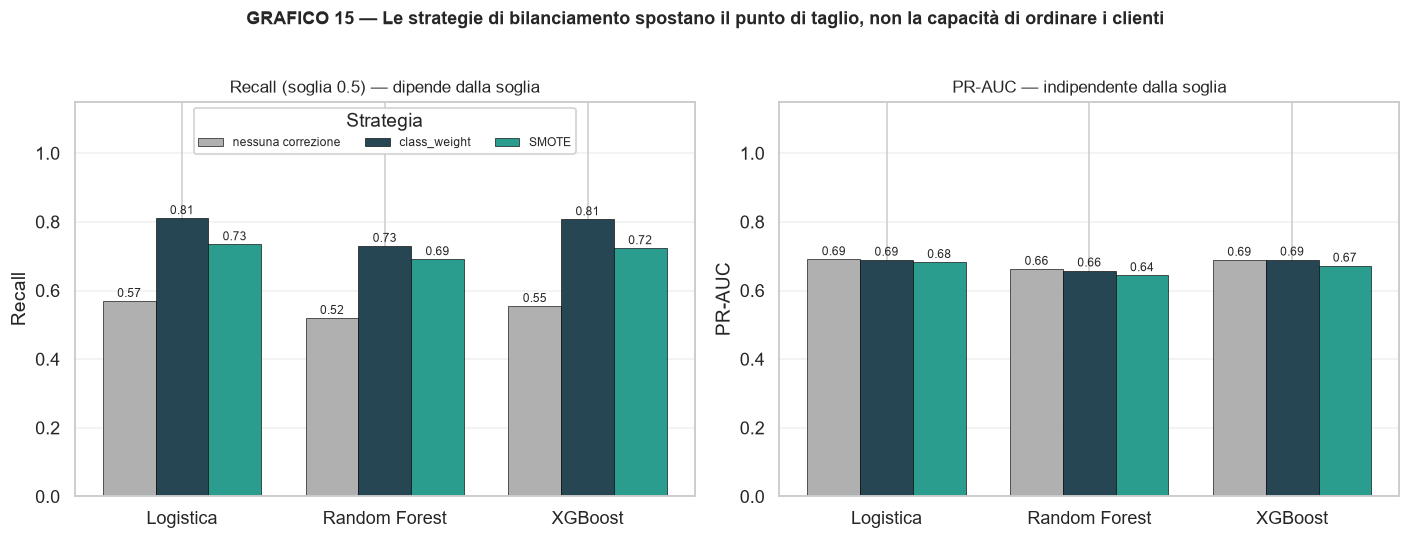

In [33]:
# GRAFICO 15 — Effetto delle strategie di bilanciamento su recall e PR-AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

modelli = ["Logistica", "Random Forest", "XGBoost"]
colori_strategia = {
    "nessuna correzione": "#B0B0B0",
    "class_weight": PALETTE_CHURN["Resta (No)"],
    "SMOTE": COLOR_NEUTRO,
}
larghezza = 0.26
posizioni = np.arange(len(modelli))

for ax, metrica, titolo in [
    (ax1, "Recall", "Recall (soglia 0.5) — dipende dalla soglia"),
    (ax2, "PR-AUC", "PR-AUC — indipendente dalla soglia"),
]:
    for k, strategia in enumerate(STRATEGIE):
        valori = [
            confronto_bilanciamento.loc[
                (confronto_bilanciamento["Modello"] == m)
                & (confronto_bilanciamento["Strategia"] == strategia), metrica
            ].iloc[0]
            for m in modelli
        ]
        barre = ax.bar(posizioni + (k - 1) * larghezza, valori, larghezza,
                       label=strategia, color=colori_strategia[strategia],
                       edgecolor="black", linewidth=0.4)
        for barra, valore in zip(barre, valori):
            ax.text(barra.get_x() + barra.get_width() / 2, valore + 0.012,
                    f"{valore:.2f}", ha="center", fontsize=8)

    ax.set_xticks(posizioni)
    ax.set_xticklabels(modelli)
    ax.set_ylim(0, 1.15)          # spazio sopra le barre per legenda ed etichette
    ax.set_ylabel(metrica)
    ax.set_title(titolo, fontsize=11)
    ax.grid(axis="y", alpha=0.3)

ax1.legend(title="Strategia", loc="upper center", ncol=3, fontsize=8, framealpha=0.95)
plt.suptitle("GRAFICO 15 — Le strategie di bilanciamento spostano il punto di taglio, "
             "non la capacità di ordinare i clienti", fontsize=12, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Verdetto: `class_weight` confermato, ma per il motivo giusto

La tabella dice tre cose, e nessuna delle tre si vedeva ragionando a priori.

**1. Le due correzioni fanno la stessa cosa: comprano recall pagando in precision.** `class_weight` porta il recall da 0.57 a 0.81 sulla Logistica (+0.24) e da 0.56 a 0.81 su XGBoost (+0.25), ma perde 0.14 punti di precision su entrambi. SMOTE si muove nella stessa direzione, più piano: +0.17 di recall, −0.09 di precision.

**2. La PR-AUC non si muove.** Con `class_weight` varia di −0.001 sulla Logistica, −0.005 sul Random Forest, +0.001 su XGBoost: rumore. È il risultato più importante della tabella, perché dice che **nessuna delle due strategie rende il modello più bravo a distinguere i churner**. La capacità di ordinare i clienti dal più al meno rischioso è già tutta lì nei dati; quello che le correzioni spostano è il punto in cui il modello smette di dire "resta" e comincia a dire "abbandona". Che è esattamente la decisione che in Fase 4 prendo in modo esplicito, scegliendo la soglia in base ai costi — invece di lasciarla decidere di sbieco a una strategia di bilanciamento.

**3. SMOTE peggiora leggermente la PR-AUC su tutti e tre i modelli** (−0.008, −0.018, −0.017). I churner sintetici, interpolati tra churner reali vicini, non aggiungono informazione che non ci fosse già, e un po' di struttura la sporcano. C'è anche una ragione tecnica specifica di questo dataset: SMOTE interpola *tutte* le colonne, comprese le 22 binarie e one-hot, e un cliente sintetico con `Contract_Two year = 0.37` non corrisponde a nessun contratto esistente. Esiste una variante pensata per i dati misti (SMOTE-NC), che però andrebbe applicata prima dell'encoding e complicherebbe la pipeline per un guadagno che qui non si intravede.

**Scelgo `class_weight`.** A parità sostanziale di PR-AUC ottiene il recall più alto di tutti (0.811 contro 0.734 di SMOTE sulla Logistica), non tocca i dati, non aggiunge una dipendenza, funziona identico su tutti e tre gli algoritmi e non ha parametri da tarare.

Un'onestà dovuta: sulla Logistica l'F1 di SMOTE è marginalmente più alto (0.653 contro 0.648). Non cambia la decisione, perché l'F1 pesa recall e precision allo stesso modo, mentre in Fase 4 stabilisco che un churner perso costa circa cinque volte un falso allarme. Con quei pesi, il recall vale più della precision, e la classifica si ribalta.

## Modello 1 — Regressione Logistica

Perché partire da qui: è la baseline più semplice (se un modello complesso non la batte chiaramente, non vale la pena usarlo); le feature ingegnerizzate dovrebbero essere già linearmente informative; i coefficienti sono interpretabili direttamente (utile in Fase 5).

Iperparametri: `class_weight='balanced'`, `max_iter=1000`, `solver='liblinear'`.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve,
)

# Tutte le decisioni restano nel training set: ogni cliente riceve una
# probabilità da un modello che non lo ha visto durante il fit del fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg = Pipeline([
    ("prep", crea_preprocessore()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear",
        random_state=42,
    )),
])
cv_auc_logreg = cross_val_score(
    logreg, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1
)
proba_logreg_oof = cross_val_predict(
    logreg, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1
)[:, 1]
pred_logreg_oof = (proba_logreg_oof >= 0.5).astype(int)
logreg.fit(X_train, y_train)

print("Regressione Logistica — predizioni out-of-fold sul training set")
print(f"  CV ROC-AUC (5-fold) : {cv_auc_logreg.mean():.4f} ± {cv_auc_logreg.std():.4f}")
print(f"  OOF Precision       : {precision_score(y_train, pred_logreg_oof):.3f}")
print(f"  OOF Recall          : {recall_score(y_train, pred_logreg_oof):.3f}")
print(f"  OOF F1              : {f1_score(y_train, pred_logreg_oof):.3f}")
print(f"  OOF PR-AUC          : {average_precision_score(y_train, proba_logreg_oof):.3f}")

Regressione Logistica — predizioni out-of-fold sul training set
  CV ROC-AUC (5-fold) : 0.8617 ± 0.0124
  OOF Precision       : 0.539
  OOF Recall          : 0.811
  OOF F1              : 0.648
  OOF PR-AUC          : 0.687


**Lettura:** le metriche sono calcolate su predizioni out-of-fold del training set. Ogni riga viene valutata da un modello addestrato sugli altri quattro fold; il test set non viene consultato. Questo rende le probabilità utilizzabili per confrontare i modelli e, nella fase successiva, scegliere la soglia senza contaminare la verifica finale.

## Modello 2 — Random Forest

Perché confrontarlo: natura diversa dalla logistica (cattura interazioni non lineari senza specificarle a mano); bagging (alberi indipendenti) vs boosting; robusto ai default.

Iperparametri: 400 alberi, `min_samples_leaf=2`, `class_weight='balanced'`.

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("prep", crea_preprocessore()),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=1,
        random_state=42,
    )),
])
cv_auc_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
proba_rf_oof = cross_val_predict(
    rf, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1
)[:, 1]
pred_rf_oof = (proba_rf_oof >= 0.5).astype(int)
rf.fit(X_train, y_train)

print("Random Forest — predizioni out-of-fold sul training set")
print(f"  CV ROC-AUC (5-fold) : {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}")
print(f"  OOF Precision       : {precision_score(y_train, pred_rf_oof):.3f}")
print(f"  OOF Recall          : {recall_score(y_train, pred_rf_oof):.3f}")
print(f"  OOF F1              : {f1_score(y_train, pred_rf_oof):.3f}")
print(f"  OOF PR-AUC          : {average_precision_score(y_train, proba_rf_oof):.3f}")

Random Forest — predizioni out-of-fold sul training set
  CV ROC-AUC (5-fold) : 0.8513 ± 0.0105
  OOF Precision       : 0.569
  OOF Recall          : 0.730
  OOF F1              : 0.640
  OOF PR-AUC          : 0.656


**Lettura:** il Random Forest viene confrontato alle stesse condizioni della Logistica, sulle medesime partizioni out-of-fold. La scelta non dipende quindi dal test finale, ma dalla capacità di generalizzare all'interno del solo training set.

## Modello 3 — XGBoost

Perché aggiungerlo: stato dell'arte sui dati tabellari; costruisce alberi in sequenza correggendo gli errori del precedente (opposto filosofico del RF); ha `scale_pos_weight` per lo sbilanciamento.

Faccio un mini-tuning manuale su una piccola griglia (7 configurazioni: profondità basse, learning rate piccoli compensati da più alberi, regolarizzazione L2).

In [36]:
from xgboost import XGBClassifier

# Griglia di configurazioni da provare (piccola, ragionata)
configurazioni = [
    dict(n_estimators=200, max_depth=3, learning_rate=0.10, reg_lambda=1.0),
    dict(n_estimators=400, max_depth=3, learning_rate=0.05, reg_lambda=1.0),
    dict(n_estimators=200, max_depth=4, learning_rate=0.05, reg_lambda=1.0),
    dict(n_estimators=300, max_depth=4, learning_rate=0.03, reg_lambda=1.0),
    dict(n_estimators=500, max_depth=3, learning_rate=0.03, reg_lambda=2.0),
    dict(n_estimators=200, max_depth=5, learning_rate=0.05, reg_lambda=2.0),
    dict(n_estimators=600, max_depth=3, learning_rate=0.02, reg_lambda=3.0),
]

print("Mini-tuning XGBoost (CV ROC-AUC 5-fold su train):")
migliore_score = -1.0
migliore_cfg = None

for cfg in configurazioni:
    modello = Pipeline([
        ("prep", crea_preprocessore()),
        ("clf", XGBClassifier(
            **cfg,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42, n_jobs=1,
        )),
    ])
    scores = cross_val_score(modello, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    m = scores.mean()
    print(f"  n_est={cfg['n_estimators']:>3}, depth={cfg['max_depth']}, "
          f"lr={cfg['learning_rate']:.2f}, l2={cfg['reg_lambda']:.0f}"
          f"  → {m:.4f} ± {scores.std():.4f}")
    if m > migliore_score:
        migliore_score = m
        migliore_cfg = cfg

print(f"\nConfigurazione vincente: {migliore_cfg}")
print(f"CV ROC-AUC: {migliore_score:.4f}")

Mini-tuning XGBoost (CV ROC-AUC 5-fold su train):


  n_est=200, depth=3, lr=0.10, l2=1  → 0.8600 ± 0.0108


  n_est=400, depth=3, lr=0.05, l2=1  → 0.8612 ± 0.0097


  n_est=200, depth=4, lr=0.05, l2=1  → 0.8620 ± 0.0098


  n_est=300, depth=4, lr=0.03, l2=1  → 0.8630 ± 0.0095


  n_est=500, depth=3, lr=0.03, l2=2  → 0.8634 ± 0.0101


  n_est=200, depth=5, lr=0.05, l2=2  → 0.8593 ± 0.0100


  n_est=600, depth=3, lr=0.02, l2=3  → 0.8641 ± 0.0098

Configurazione vincente: {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.02, 'reg_lambda': 3.0}
CV ROC-AUC: 0.8641


In [37]:
# Configurazione XGBoost selezionata esclusivamente con CV sul training set
xgb = Pipeline([
    ("prep", crea_preprocessore()),
    ("clf", XGBClassifier(
        **migliore_cfg,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42, n_jobs=1,
    )),
])
cv_auc_xgb = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
proba_xgb_oof = cross_val_predict(
    xgb, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1
)[:, 1]
pred_xgb_oof = (proba_xgb_oof >= 0.5).astype(int)
xgb.fit(X_train, y_train)

print("XGBoost — predizioni out-of-fold sul training set")
print(f"  CV ROC-AUC (5-fold) : {cv_auc_xgb.mean():.4f} ± {cv_auc_xgb.std():.4f}")
print(f"  OOF Precision       : {precision_score(y_train, pred_xgb_oof):.3f}")
print(f"  OOF Recall          : {recall_score(y_train, pred_xgb_oof):.3f}")
print(f"  OOF F1              : {f1_score(y_train, pred_xgb_oof):.3f}")
print(f"  OOF PR-AUC          : {average_precision_score(y_train, proba_xgb_oof):.3f}")

XGBoost — predizioni out-of-fold sul training set
  CV ROC-AUC (5-fold) : 0.8641 ± 0.0098
  OOF Precision       : 0.528
  OOF Recall          : 0.819
  OOF F1              : 0.642
  OOF PR-AUC          : 0.688


**Lettura:** il mini-tuning e la stima delle prestazioni di XGBoost sono entrambi confinati al training set. Le probabilità out-of-fold saranno usate insieme a quelle della Logistica per la decisione economica; il test rimane sigillato fino a quando modello e soglia non sono congelati.

## Confronto tra i tre modelli

Tabella riassuntiva più curve ROC e Precision-Recall sovrapposte — entrambe soglia-invarianti, quindi confrontano i modelli meglio delle metriche puntuali a 0.5.

In [38]:
# Tabella di confronto su predizioni out-of-fold, senza usare il test
def metriche_oof(nome, y_pred, y_proba, cv_scores):
    return {
        "Modello": nome,
        "CV ROC-AUC": f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
        "OOF Accuracy": accuracy_score(y_train, y_pred),
        "OOF Precision": precision_score(y_train, y_pred),
        "OOF Recall": recall_score(y_train, y_pred),
        "OOF F1": f1_score(y_train, y_pred),
        "OOF PR-AUC": average_precision_score(y_train, y_proba),
    }

tabella = pd.DataFrame([
    metriche_oof("Logistica", pred_logreg_oof, proba_logreg_oof, cv_auc_logreg),
    metriche_oof("Random Forest", pred_rf_oof, proba_rf_oof, cv_auc_rf),
    metriche_oof("XGBoost", pred_xgb_oof, proba_xgb_oof, cv_auc_xgb),
])
for col in ["OOF Accuracy", "OOF Precision", "OOF Recall", "OOF F1", "OOF PR-AUC"]:
    tabella[col] = tabella[col].round(3)
print(tabella.to_string(index=False))

# Regola one-standard-error: se un modello più semplice rientra entro un errore
# standard dal migliore, non considero dimostrato il vantaggio di complessità.
limite_un_se = cv_auc_xgb.mean() - cv_auc_xgb.std() / np.sqrt(cv.get_n_splits())
logistica_entro_un_se = cv_auc_logreg.mean() >= limite_un_se
print(f"\nLimite one-SE del miglior modello: {limite_un_se:.4f}")
print(f"Logistica entro one-SE: {logistica_entro_un_se}")

      Modello      CV ROC-AUC  OOF Accuracy  OOF Precision  OOF Recall  OOF F1  OOF PR-AUC
    Logistica 0.8617 ± 0.0124         0.766          0.539       0.811   0.648       0.687
Random Forest 0.8513 ± 0.0105         0.782          0.569       0.730   0.640       0.656
      XGBoost 0.8641 ± 0.0098         0.758          0.528       0.819   0.642       0.688

Limite one-SE del miglior modello: 0.8597
Logistica entro one-SE: True


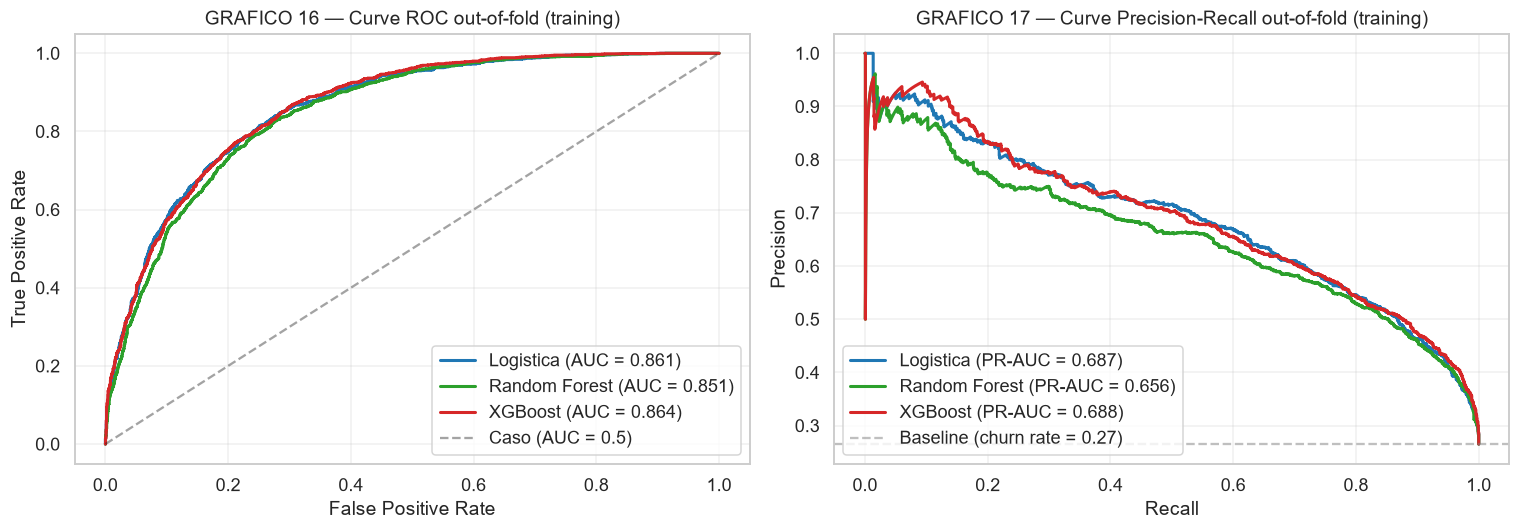

In [39]:
# GRAFICO 16 e 17 — curve out-of-fold sul training set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

modelli_oof = [
    ("Logistica", proba_logreg_oof, "#1f77b4"),
    ("Random Forest", proba_rf_oof, "#2ca02c"),
    ("XGBoost", proba_xgb_oof, "#d62728"),
]
for nome, proba, colore in modelli_oof:
    fpr, tpr, _ = roc_curve(y_train, proba)
    auc = roc_auc_score(y_train, proba)
    ax1.plot(fpr, tpr, color=colore, linewidth=2, label=f"{nome} (AUC = {auc:.3f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Caso (AUC = 0.5)")
ax1.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
        title="GRAFICO 16 — Curve ROC out-of-fold (training)")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

for nome, proba, colore in modelli_oof:
    prec, rec, _ = precision_recall_curve(y_train, proba)
    ap = average_precision_score(y_train, proba)
    ax2.plot(rec, prec, color=colore, linewidth=2, label=f"{nome} (PR-AUC = {ap:.3f})")
ax2.axhline(y_train.mean(), linestyle="--", color="gray", alpha=0.5,
            label=f"Baseline (churn rate = {y_train.mean():.2f})")
ax2.set(xlabel="Recall", ylabel="Precision",
        title="GRAFICO 17 — Curve Precision-Recall out-of-fold (training)")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretazione:** il confronto avviene sulle stesse 5 partizioni out-of-fold. XGBoost e Logistica hanno prestazioni molto vicine e il loro scarto va letto insieme alla variabilità tra i fold, non come una vittoria automatica del modello più complesso. Il Random Forest rimane il candidato meno adatto al trade-off retention. La decisione economica tra Logistica e XGBoost viene presa nella Fase 4 sulle probabilità OOF, prima di aprire il test.

## Sintesi Fase 3 — cosa consegno alla Fase 4

Tre pipeline addestrate sull'intero training set e tre vettori di probabilità out-of-fold: `proba_logreg_oof`, `proba_rf_oof`, `proba_xgb_oof`.

Lo sbilanciamento è stato confrontato numericamente con baseline e SMOTE. Il tuning di XGBoost e il confronto tra modelli sono avvenuti soltanto nel training set. **Il test non è ancora stato usato per scegliere modello, iperparametri o soglia.**

Per la Fase 4 restano due candidati, Logistica e XGBoost. La soglia e il modello finale saranno scelti tramite costo sulle predizioni OOF; soltanto dopo verrà eseguita la valutazione finale sul test.

# Fase 4 — Selezione OOF e valutazione finale

Il test set è stato creato all'inizio e mantenuto separato. In questa fase modello e soglia vengono prima selezionati usando esclusivamente le predizioni out-of-fold del training set. Solo dopo aver congelato la decisione, il test viene aperto una volta per stimare le prestazioni finali.

## Verifica di ripartenza

Controllo che l'ambiente contenga i tre modelli allenati e le loro predizioni, come lasciato dalla Fase 3.

In [40]:
# Sanity check sugli oggetti di selezione: tutti devono riferirsi al training set
assert X_train.shape == (5634, 18)
assert X_train_proc.shape == (5634, 28)
assert X_test.shape == (1409, 18)
assert proba_logreg_oof.shape == (5634,)
assert proba_rf_oof.shape == (5634,)
assert proba_xgb_oof.shape == (5634,)
assert all(0.0 <= p.min() and p.max() <= 1.0
           for p in [proba_logreg_oof, proba_rf_oof, proba_xgb_oof])

print(f"Training per selezione OOF : {len(y_train):,} clienti")
print(f"Test finale ancora separato: {len(y_test):,} clienti")
print("Modello e soglia verranno congelati prima di calcolare le metriche sul test.")

Training per selezione OOF : 5,634 clienti
Test finale ancora separato: 1,409 clienti
Modello e soglia verranno congelati prima di calcolare le metriche sul test.


## Confusion matrix OOF a soglia 0.5

Le confusion matrix iniziali usano le predizioni out-of-fold del training set. Servono a visualizzare il trade-off dei tre modelli senza consumare il test finale.

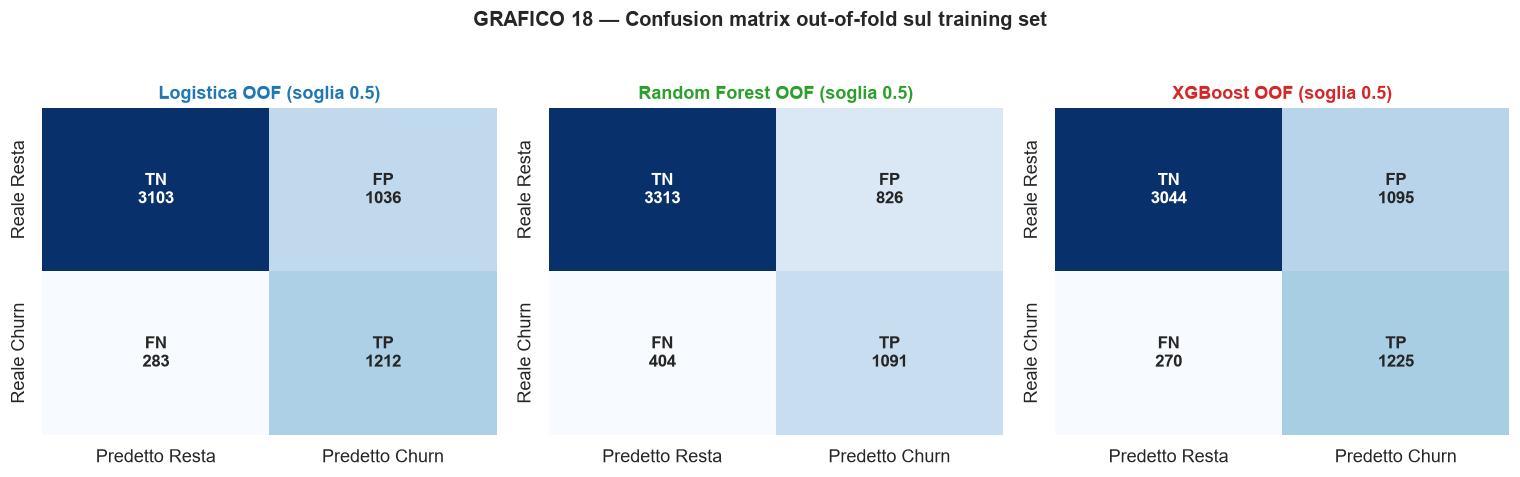

Errori OOF a soglia 0.5:
  Logistica        FN =  283   FP = 1036
  Random Forest    FN =  404   FP =  826
  XGBoost          FN =  270   FP = 1095


In [41]:
# GRAFICO 18 — Confusion matrix OOF dei 3 modelli a soglia 0.5
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
modelli_soglia05 = [
    ("Logistica", pred_logreg_oof, "#1f77b4"),
    ("Random Forest", pred_rf_oof, "#2ca02c"),
    ("XGBoost", pred_xgb_oof, "#d62728"),
]
for ax, (nome, pred, colore) in zip(axes, modelli_soglia05):
    cm = confusion_matrix(y_train, pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(
        cm, annot=[[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]],
        fmt="", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Predetto Resta", "Predetto Churn"],
        yticklabels=["Reale Resta", "Reale Churn"],
        annot_kws={"fontsize": 11, "weight": "bold"},
    )
    ax.set_title(f"{nome} OOF (soglia 0.5)", fontsize=12, weight="bold", color=colore)
plt.suptitle("GRAFICO 18 — Confusion matrix out-of-fold sul training set",
             fontsize=13, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

print("Errori OOF a soglia 0.5:")
for nome, pred, _ in modelli_soglia05:
    _, fp, fn, _ = confusion_matrix(y_train, pred).ravel()
    print(f"  {nome:<15}  FN = {fn:>4}   FP = {fp:>4}")

## Quanto costa un falso positivo, quanto un falso negativo

Per confrontare soglie diverse costruisco uno scenario di costo puramente ipotetico. Il modello non decide chi contattare; il calcolo assegna soltanto pesi diversi ai tipi di errore:

| Cosa succede | Nome tecnico | Lettura nello scenario didattico |
|---|---|---|
| Predico "resta", resta nel campione | TN | Nessuna penalità nello scenario |
| Predico "resta", ma abbandona | **FN** | Penalità relativa più alta |
| Predico "churn", abbandona | TP | Nessuna penalità nello scenario |
| Predico "churn", ma resta | **FP** | Penalità relativa più bassa |

Non dispongo di margini, costi di contatto o effetti reali delle offerte: le unità seguenti non sono valuta né una stima economica aziendale.

Rapporto di scenario: `c_FN : c_FP = 5:1`. Lo uso come baseline didattica e svolgo una sensitivity analysis; prima di qualunque decisione servirebbero valori aziendali validati.

$$\text{costo}(t) = c_{FN}\cdot FN(t) + c_{FP}\cdot FP(t) \qquad t^\star = \arg\min_t \text{costo}(t)$$

Con `c_FN > c_FP` conviene abbassare la soglia rispetto a 0.5: più clienti flaggati come "churn" → più TP e FP, meno FN.

## Scelta della soglia sul training tramite predizioni out-of-fold

Scandisco 201 soglie tra 0.01 e 0.99 sui due candidati. Il costo viene calcolato sulle predizioni OOF: ogni probabilità arriva da un modello che non ha visto quella riga. La soglia risultante viene quindi congelata prima della valutazione finale.

In [42]:
def costo_a_soglia(y_true, y_proba, soglia, c_fn, c_fp):
    y_true = np.asarray(y_true)
    y_pred = (y_proba >= soglia).astype(int)
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return c_fn * fn + c_fp * fp, fn, fp


def cerca_soglia_ottima(y_true, y_proba, c_fn, c_fp, n=201):
    soglie = np.linspace(0.01, 0.99, n)
    costi = np.array([costo_a_soglia(y_true, y_proba, s, c_fn, c_fp)[0] for s in soglie])
    idx = int(costi.argmin())
    return soglie[idx], costi[idx], soglie, costi


C_FN, C_FP = 5.0, 1.0
t_logreg, costo_min_logreg, soglie_grid, costi_logreg = cerca_soglia_ottima(
    y_train, proba_logreg_oof, C_FN, C_FP
)
t_xgb, costo_min_xgb, _, costi_xgb = cerca_soglia_ottima(
    y_train, proba_xgb_oof, C_FN, C_FP
)
costo_logreg_05 = costo_a_soglia(y_train, proba_logreg_oof, 0.5, C_FN, C_FP)[0]
costo_xgb_05 = costo_a_soglia(y_train, proba_xgb_oof, 0.5, C_FN, C_FP)[0]

print(f"Rapporto costi assunto: c_FN = {C_FN:.0f}, c_FP = {C_FP:.0f}")
print("Selezione su 5.634 predizioni out-of-fold del training set:\n")
print(f"Logistica  → soglia = {t_logreg:.3f}, costo OOF = {costo_min_logreg:.0f} "
      f"(a 0.5: {costo_logreg_05:.0f})")
print(f"XGBoost    → soglia = {t_xgb:.3f}, costo OOF = {costo_min_xgb:.0f} "
      f"(a 0.5: {costo_xgb_05:.0f})")

Rapporto costi assunto: c_FN = 5, c_FP = 1
Selezione su 5.634 predizioni out-of-fold del training set:

Logistica  → soglia = 0.426, costo OOF = 2274 (a 0.5: 2451)
XGBoost    → soglia = 0.378, costo OOF = 2205 (a 0.5: 2445)


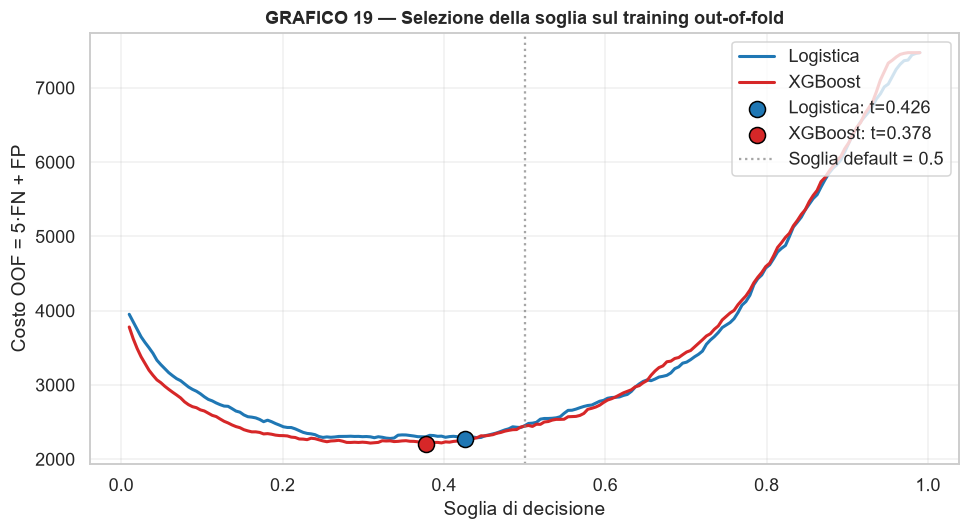

In [43]:
# GRAFICO 19 — costo OOF al variare della soglia
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(soglie_grid, costi_logreg, color="#1f77b4", linewidth=2, label="Logistica")
ax.plot(soglie_grid, costi_xgb, color="#d62728", linewidth=2, label="XGBoost")
ax.scatter([t_logreg], [costo_min_logreg], color="#1f77b4", s=110, zorder=5,
           edgecolor="black", label=f"Logistica: t={t_logreg:.3f}")
ax.scatter([t_xgb], [costo_min_xgb], color="#d62728", s=110, zorder=5,
           edgecolor="black", label=f"XGBoost: t={t_xgb:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.7, label="Soglia default = 0.5")
ax.set_xlabel("Soglia di decisione")
ax.set_ylabel("Costo OOF = 5·FN + FP")
ax.set_title("GRAFICO 19 — Selezione della soglia sul training out-of-fold",
             fontsize=12, weight="bold")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Metriche out-of-fold alle soglie selezionate

Prima di aprire il test confronto i candidati alle soglie ottimizzate sul training. Questi numeri servono alla decisione; non sono le metriche finali pubblicate.

In [44]:
pred_logreg_oof_opt = (proba_logreg_oof >= t_logreg).astype(int)
pred_xgb_oof_opt = (proba_xgb_oof >= t_xgb).astype(int)

def riga_metriche_oof(nome, y_pred, soglia):
    tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
    return {
        "Modello": nome,
        "Soglia": round(soglia, 3),
        "Precision": round(precision_score(y_train, y_pred), 3),
        "Recall": round(recall_score(y_train, y_pred), 3),
        "F1": round(f1_score(y_train, y_pred), 3),
        "FN": fn,
        "FP": fp,
        "Costo OOF (5·FN+FP)": int(5 * fn + fp),
    }

confronto_soglie = pd.DataFrame([
    riga_metriche_oof("Logistica @0.5", pred_logreg_oof, 0.5),
    riga_metriche_oof("Logistica @OOF", pred_logreg_oof_opt, t_logreg),
    riga_metriche_oof("XGBoost @0.5", pred_xgb_oof, 0.5),
    riga_metriche_oof("XGBoost @OOF", pred_xgb_oof_opt, t_xgb),
])
print(confronto_soglie.to_string(index=False))

       Modello  Soglia  Precision  Recall    F1  FN   FP  Costo OOF (5·FN+FP)
Logistica @0.5   0.500      0.539   0.811 0.648 283 1036                 2451
Logistica @OOF   0.426      0.503   0.868 0.636 198 1284                 2274
  XGBoost @0.5   0.500      0.528   0.819 0.642 270 1095                 2445
  XGBoost @OOF   0.378      0.491   0.889 0.633 166 1375                 2205


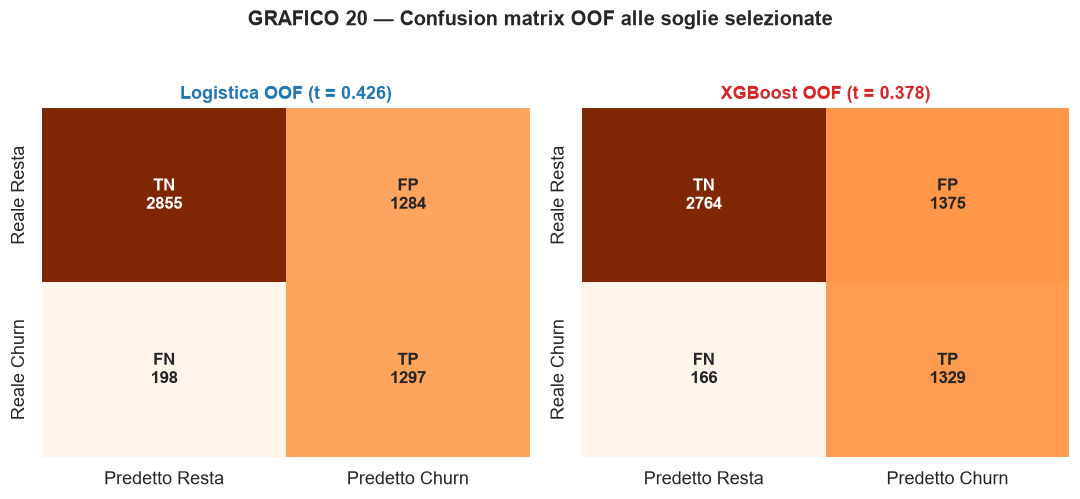

In [45]:
# GRAFICO 20 — confusion matrix OOF alle soglie selezionate
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (nome, pred, soglia, colore) in zip(axes, [
    ("Logistica", pred_logreg_oof_opt, t_logreg, "#1f77b4"),
    ("XGBoost", pred_xgb_oof_opt, t_xgb, "#d62728"),
]):
    cm = confusion_matrix(y_train, pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(
        cm, annot=[[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]],
        fmt="", cmap="Oranges", cbar=False, ax=ax,
        xticklabels=["Predetto Resta", "Predetto Churn"],
        yticklabels=["Reale Resta", "Reale Churn"],
        annot_kws={"fontsize": 11, "weight": "bold"},
    )
    ax.set_title(f"{nome} OOF (t = {soglia:.3f})", fontsize=12, weight="bold", color=colore)
plt.suptitle("GRAFICO 20 — Confusion matrix OOF alle soglie selezionate",
             fontsize=13, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Sensitivity: e se il rapporto FN:FP fosse diverso?

Il 5:1 è un'ipotesi didattica, non una stima aziendale. Controllo cosa succede negli altri rapporti esplorati: la stabilità della scelta in questa griglia indica soltanto minore sensibilità locale al parametro, non robustezza economica o operativa.

In [46]:
rapporti = [2, 3, 5, 8, 10]
righe_sensitivity = []
for r in rapporti:
    t_L, c_L, _, _ = cerca_soglia_ottima(y_train, proba_logreg_oof, r, 1.0)
    t_X, c_X, _, _ = cerca_soglia_ottima(y_train, proba_xgb_oof, r, 1.0)
    righe_sensitivity.append({
        "Rapporto c_FN:c_FP": f"{r}:1",
        "Soglia Log": round(t_L, 3),
        "Costo Log OOF": int(c_L),
        "Soglia XGB": round(t_X, 3),
        "Costo XGB OOF": int(c_X),
        "Vince": "Logistica" if c_L < c_X else ("XGBoost" if c_X < c_L else "pari"),
    })
sensitivity = pd.DataFrame(righe_sensitivity)
print("Sensitivity OOF al rapporto FN:FP:\n")
print(sensitivity.to_string(index=False))

Sensitivity OOF al rapporto FN:FP:

Rapporto c_FN:c_FP  Soglia Log  Costo Log OOF  Soglia XGB  Costo XGB OOF   Vince
               2:1       0.618           1561       0.569           1558 XGBoost
               3:1       0.446           1866       0.422           1854 XGBoost
               5:1       0.426           2274       0.378           2205 XGBoost
               8:1       0.250           2549       0.177           2512 XGBoost
              10:1       0.250           2719       0.162           2609 XGBoost


## Scelta finale prima di aprire il test

La scelta è presa sui risultati out-of-fold sopra riportati. XGBoost riduce il costo OOF da 2.274 a 2.205 unità al rapporto 5:1, circa il 3,0%, e vince in tutti i rapporti esplorati. Riporto quindi il vantaggio nelle unità dello scenario ipotetico, che non rappresentano denaro o risparmio aziendale osservato. Sul ranking, però, la differenza di ROC-AUC è 0,0024 e la Logistica rientra nella fascia one-standard-error del miglior modello. Con costi non validati, considero il 3,0% insufficiente per giustificare una pipeline più complessa e spiegazioni SHAP obbligatorie nel runtime.

Applico quindi la regola dichiarata: tra modelli statisticamente equivalenti entro un errore standard, scelgo quello più semplice. Se l'azienda validasse costi reali e il vantaggio di XGBoost persistesse su nuovi dati, questa decisione andrebbe riesaminata.

**Decisione congelata:** Regressione Logistica con `class_weight='balanced'`; soglia `t_logreg` selezionata sulle predizioni OOF al rapporto 5:1. Da questo punto il test viene usato una sola volta per la stima finale, senza ritarare modello o soglia in base al risultato.

## Sintesi della selezione

Sono congelati prima del test: modello, iperparametri, rapporto di costo, soglia e regola di tie-break. Le probabilità OOF della Logistica saranno anche la popolazione di riferimento per determinare i nove cut-point dei decili di analisi.

Il test finale produrrà le metriche da riportare, ma non potrà cambiare la decisione. Questa separazione evita che lo stesso insieme di clienti venga usato sia per ottimizzare sia per valutare il sistema.

## Valutazione finale sul test sigillato

Ora applico le pipeline già addestrate sul training completo. La soglia della Logistica è quella selezionata OOF e non viene modificata dopo aver visto queste metriche.

Metriche finali sul test, senza ritaratura:

            Modello  Soglia congelata  ROC-AUC  PR-AUC  Precision  Recall    F1  FN  FP  Costo test (5·FN+FP)
          Logistica             0.426    0.854   0.675      0.490   0.837 0.618  61 326                   631
XGBoost (controllo)             0.378    0.854   0.670      0.481   0.877 0.621  46 354                   584


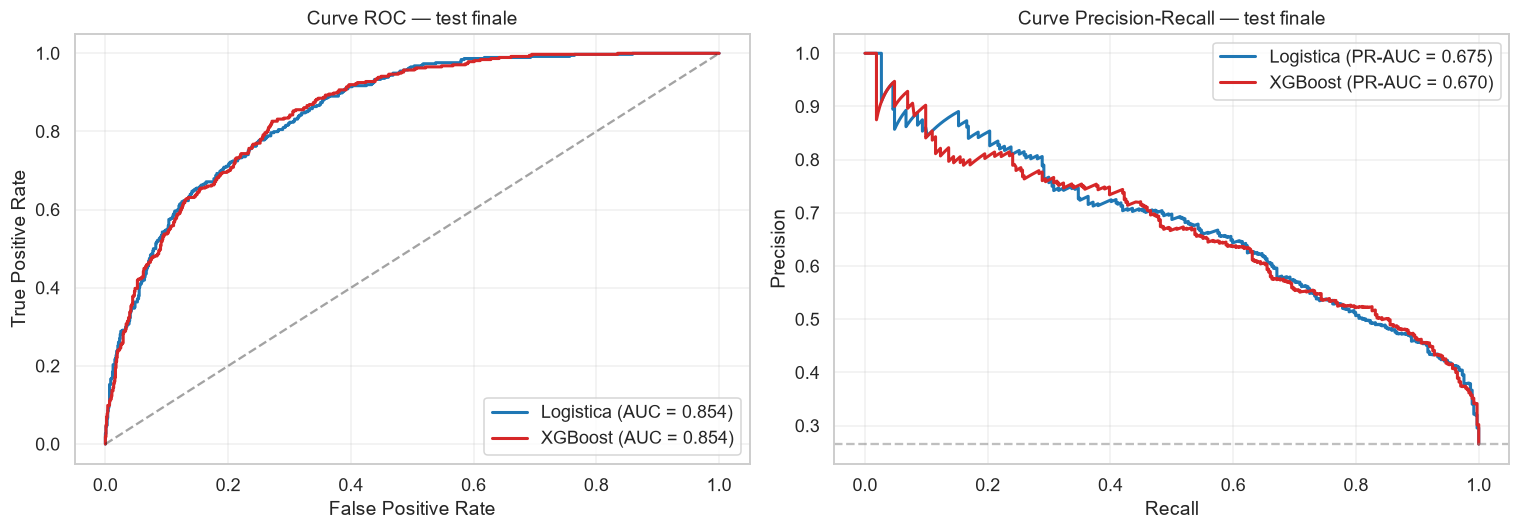

In [47]:
# Prima e unica valutazione finale sul test
proba_logreg = logreg.predict_proba(X_test)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]
proba_xgb = xgb.predict_proba(X_test)[:, 1]
pred_logreg = (proba_logreg >= 0.5).astype(int)
pred_rf = (proba_rf >= 0.5).astype(int)
pred_xgb = (proba_xgb >= 0.5).astype(int)
pred_logreg_opt = (proba_logreg >= t_logreg).astype(int)
pred_xgb_opt = (proba_xgb >= t_xgb).astype(int)

def riga_test(nome, proba, pred, soglia):
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "Modello": nome,
        "Soglia congelata": round(soglia, 3),
        "ROC-AUC": round(roc_auc_score(y_test, proba), 3),
        "PR-AUC": round(average_precision_score(y_test, proba), 3),
        "Precision": round(precision_score(y_test, pred), 3),
        "Recall": round(recall_score(y_test, pred), 3),
        "F1": round(f1_score(y_test, pred), 3),
        "FN": fn,
        "FP": fp,
        "Costo test (5·FN+FP)": int(5 * fn + fp),
    }

metriche_test_finali = pd.DataFrame([
    riga_test("Logistica", proba_logreg, pred_logreg_opt, t_logreg),
    riga_test("XGBoost (controllo)", proba_xgb, pred_xgb_opt, t_xgb),
])
print("Metriche finali sul test, senza ritaratura:\n")
print(metriche_test_finali.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for nome, proba, colore in [
    ("Logistica", proba_logreg, "#1f77b4"),
    ("XGBoost", proba_xgb, "#d62728"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, color=colore, linewidth=2,
             label=f"{nome} (AUC = {roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax2.plot(rec, prec, color=colore, linewidth=2,
             label=f"{nome} (PR-AUC = {average_precision_score(y_test, proba):.3f})")
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set(xlabel="False Positive Rate", ylabel="True Positive Rate",
        title="Curve ROC — test finale")
ax2.axhline(y_test.mean(), linestyle="--", color="gray", alpha=0.5)
ax2.set(xlabel="Recall", ylabel="Precision",
        title="Curve Precision-Recall — test finale")
for ax in (ax1, ax2):
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Fase 5 — Interpretazione e ipotesi da validare

Modello selezionato prima del test: **Regressione Logistica**, soglia OOF 0,426 al rapporto costi 5:1. Sul test finale ottiene ROC-AUC 0,854, PR-AUC 0,675, precision 0,490 e recall 0,837. XGBoost resta un controllo importante: sul test ha costo inferiore, coerente con il vantaggio OOF, ma non cambia retroattivamente la regola di selezione.

Questa fase interpreta il modello congelato, misura il lift dei decili e formula ipotesi da validare su dati futuri o con esperimenti. Le analisi successive non vengono usate per ritarare la pipeline.

## Verifica di ripartenza

Controllo che modelli, soglie e predizioni della Fase 4 siano disponibili.

In [48]:
# Sanity check: gli oggetti che mi aspetto dalla Fase 4 devono esistere e avere le forme giuste
assert hasattr(logreg.named_steps["clf"], "coef_"), "logreg non addestrato"
assert 't_logreg' in dir() and 't_xgb' in dir(), "soglie ottime mancanti"
assert pred_logreg_opt.shape == (1409,) and pred_xgb_opt.shape == (1409,)
assert list(X_train_proc.columns) == list(X_test_proc.columns), "colonne train/test disallineate"

print(f"Modello scelto      : Logistica, soglia = {t_logreg:.3f}")
print(f"Modello di controllo: XGBoost,   soglia = {t_xgb:.3f}")
print(f"Test set            : {len(y_test)} clienti, {int(y_test.sum())} churner ({y_test.mean()*100:.1f}%)")
print(f"Feature disponibili : {X_train_proc.shape[1]}")

Modello scelto      : Logistica, soglia = 0.426
Modello di controllo: XGBoost,   soglia = 0.378
Test set            : 1409 clienti, 374 churner (26.5%)
Feature disponibili : 28


## I coefficienti della Logistica scelta

Il modello è lineare: la probabilità di churn dipende dalla somma pesata delle feature. Coefficiente **positivo** → alza il rischio (driver); **negativo** → lo riduce (protettore); **vicino a zero** → non conta.

Le feature numeriche sono scalate (Fase 2), quindi i coefficienti sono direttamente confrontabili tra loro.

In [49]:
# Coefficienti della Logistica, ordinati per valore assoluto (=importanza)
coef = pd.Series(logreg.named_steps["clf"].coef_[0],
                 index=nomi_feature(logreg), name="coefficiente")
coef_ordinato = coef.reindex(coef.abs().sort_values(ascending=False).index)

print("Ranking di importanza (per |coef|):\n")
print(f"{'#':>3}  {'Feature':<45s}  {'Coef':>7s}  {'Effetto':<12s}")
print("-" * 75)
for i, (name, v) in enumerate(coef_ordinato.items(), 1):
    effetto = "→ churn" if v > 0 else "→ retention"
    print(f"{i:>3d}  {name:<45s}  {v:>+7.3f}  {effetto:<12s}")

print(f"\nIntercetta: {logreg.named_steps['clf'].intercept_[0]:.3f}")

Ranking di importanza (per |coef|):

  #  Feature                                           Coef  Effetto     
---------------------------------------------------------------------------
  1  Dependents                                      -1.619  → retention 
  2  Contract_Two year                               -0.957  → retention 
  3  Internet Service_No                             -0.928  → retention 
  4  Tenure Months                                   -0.820  → retention 
  5  Internet Service_Fiber optic                    +0.743  → churn     
  6  Contract_Month-to-month                         +0.720  → churn     
  7  Online Security                                 -0.423  → retention 
  8  Phone Service                                   -0.411  → retention 
  9  Total Charges                                   +0.405  → churn     
 10  Charge Per Tenure                               +0.387  → churn     
 11  Tech Support                                    -0.376  → retention 

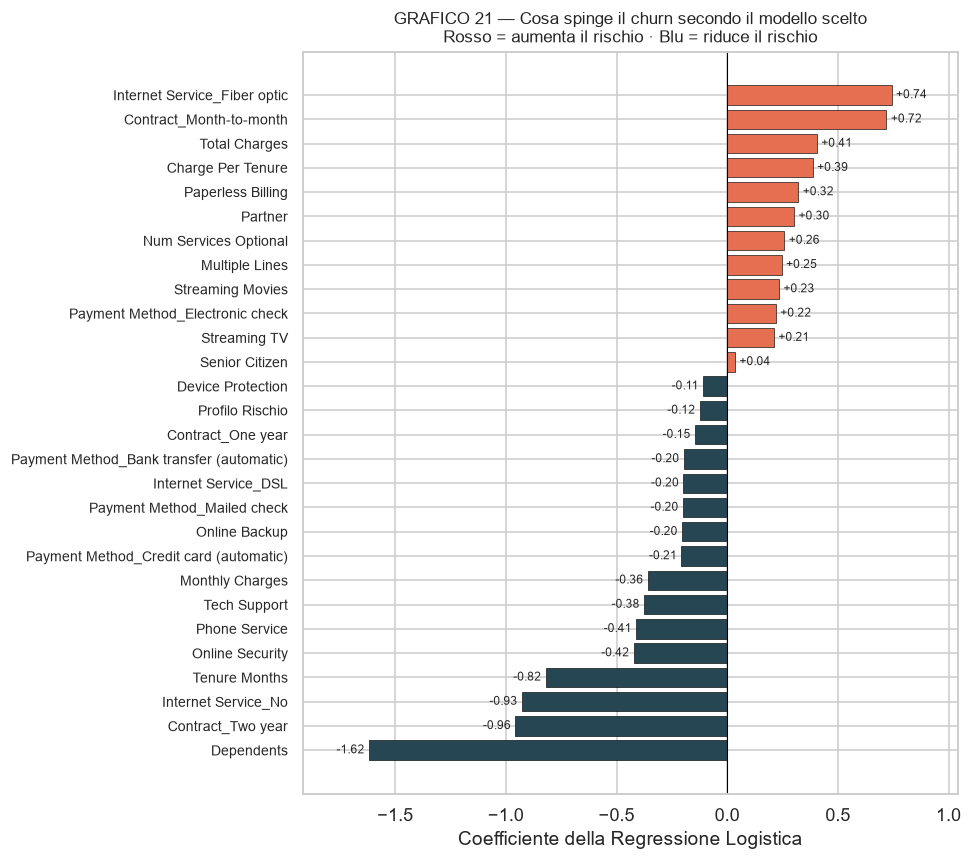

In [50]:
# GRAFICO 21 — Coefficienti della Logistica ordinati (bar chart orizzontale)
fig, ax = plt.subplots(figsize=(9, 8))

# Ordino da più negativo a più positivo per leggere dal basso verso l'alto
coef_plot = coef.sort_values()
colori = [PALETTE_CHURN["Abbandona (Yes)"] if v > 0 else PALETTE_CHURN["Resta (No)"]
          for v in coef_plot.values]

ax.barh(range(len(coef_plot)), coef_plot.values, color=colori, edgecolor="black", linewidth=0.4)
ax.set_yticks(range(len(coef_plot)))
ax.set_yticklabels(coef_plot.index, fontsize=9)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Coefficiente della Regressione Logistica")
ax.set_title("GRAFICO 21 — Cosa spinge il churn secondo il modello scelto\n"
             "Rosso = aumenta il rischio · Blu = riduce il rischio", fontsize=11)

# Annotazioni valore accanto a ciascuna barra
for i, v in enumerate(coef_plot.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)

ax.set_xlim(coef_plot.min() - 0.3, coef_plot.max() + 0.3)
plt.tight_layout()
plt.show()

**Interpretazione — cosa dice il modello.** Le prime sei feature per magnitudine:

1. **`Dependents` (−1.62)** — coefficiente più negativo: nel training, chi ha familiari a carico presenta un churn osservato inferiore.
2. **`Contract_Two year` (−0.96)** — coerente con l'EDA (2.8% vs 42.7% del mensile).
3. **`Internet Service_No` (−0.93)** — i clienti "solo telefono" abbandonano poco.
4. **`Tenure Months` (−0.82)** — nel modello, maggiore anzianità contribuisce a ridurre il punteggio.
5. **`Internet Service_Fiber optic` (+0.74)** — tra i maggiori contributi positivi al punteggio.
6. **`Contract_Month-to-month` (+0.72)** — contributo positivo, opposto a quello del biennale.

Le tre variabili "core" dell'EDA (contratto, anzianità, connessione) sono tutte in cima — conferma il memo di Fase 1.

**Alcune apparenti contraddizioni da approfondire (sezione 5.4):** `Partner` positivo nonostante il churn osservato inferiore in EDA; `Monthly Charges` negativo pur essendo più alto tra i churner; `Profilo Rischio` con coefficiente piccolo; `Senior Citizen` quasi a zero nonostante Δ +15 pp in EDA. Il modello stima contributi condizionati alle altre feature: non sono effetti causali.

## Confronto con XGBoost — le due storie coincidono?

Se i due modelli (uno lineare, uno ad alberi) raccontano storie simili sui driver del churn, ottengo una verifica di robustezza interna sul medesimo campione. Non è una conferma indipendente della realtà delle relazioni: entrambi usano gli stessi dati e possono condividerne i bias.

Per la Logistica i coefficienti bastano. Per XGBoost serve un equivalente, e qui la scelta dello strumento non è neutra:

- La **feature importance "gain"** misura quanto ogni feature riduce l'errore negli split in cui viene usata. Ha un bias documentato verso le variabili numeriche continue: `Tenure Months` ha 72 valori distinti e quindi decine di punti di taglio possibili, `Paperless Billing` ne ha due. A parità di segnale reale, la prima ha molte più occasioni di essere scelta e di accumulare gain. In più il gain è una media su tutto il modello: dice quali feature contano *in generale*, non perché sia stato classificato a rischio un cliente in particolare.
- I **valori SHAP** partono da un'idea diversa: ripartiscono la predizione tra le feature secondo la teoria dei giochi cooperativi, trattando ogni feature come un giocatore che contribuisce al risultato. La proprietà che li rende utili è che i contributi **sommano esattamente alla predizione del singolo cliente**: sono confrontabili tra feature di tipo diverso e si leggono a due livelli, globale (media dei valori assoluti su tutti i clienti) e locale (questo cliente, questa previsione).

Uso SHAP per il confronto, e mostro anche di quanto i due strumenti divergono sullo stesso identico modello.

In [51]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
import shap

# TreeExplainer: per i modelli ad alberi il calcolo è esatto e veloce.
# Lavora sulle feature già trasformate, cioè quelle che il modello vede davvero.
modello_xgb = xgb.named_steps["clf"]
explainer_xgb = shap.TreeExplainer(modello_xgb)
shap_xgb = explainer_xgb(X_test_proc)

# Importanza globale secondo SHAP = media dei valori assoluti, normalizzata a somma 1
imp_shap = pd.Series(np.abs(shap_xgb.values).mean(axis=0), index=X_test_proc.columns)
imp_shap = imp_shap / imp_shap.sum()

# La stessa importanza secondo il gain, per confronto
imp_gain = pd.Series(modello_xgb.get_booster().get_score(importance_type="gain"))
imp_gain = (imp_gain / imp_gain.sum()).reindex(X_test_proc.columns).fillna(0)

confronto_xgb = pd.DataFrame({
    "rank_shap": imp_shap.rank(ascending=False).astype(int),
    "imp_shap": imp_shap,
    "rank_gain": imp_gain.rank(ascending=False).astype(int),
    "imp_gain": imp_gain,
})
confronto_xgb["salto"] = confronto_xgb["rank_gain"] - confronto_xgb["rank_shap"]

print("XGBoost — top 10 secondo SHAP, con a fianco la posizione secondo il gain:\n")
print(confronto_xgb.sort_values("rank_shap").head(10).round(3).to_string())

print("\nLe 5 feature su cui i due strumenti divergono di più:")
piu_lontane = confronto_xgb["salto"].abs().sort_values(ascending=False).index[:5]
print(confronto_xgb.loc[piu_lontane].round(3).to_string())

XGBoost — top 10 secondo SHAP, con a fianco la posizione secondo il gain:

                                 rank_shap  imp_shap  rank_gain  imp_gain  salto
Contract_Month-to-month                  1     0.176          1     0.325      0
Charge Per Tenure                        2     0.156          6     0.046      4
Dependents                               3     0.154          5     0.053      2
Internet Service_Fiber optic             4     0.052          2     0.105     -2
Monthly Charges                          5     0.048         17     0.011     12
Contract_Two year                        6     0.047          4     0.065     -2
Payment Method_Electronic check          7     0.045          8     0.036      1
Tenure Months                            8     0.041         18     0.011     10
Online Security                          9     0.033         11     0.016      2
Paperless Billing                       10     0.031         10     0.021      0

Le 5 feature su cui i due strumen

In [52]:
# Da dove nasce la divergenza: quante volte il modello usa davvero ogni feature.
# "gain" in XGBoost è il guadagno MEDIO per split, quindi dipende dal denominatore.
booster = modello_xgb.get_booster()
diagnosi = pd.DataFrame({
    "n_split": pd.Series(booster.get_score(importance_type="weight")),
    "gain_medio": pd.Series(booster.get_score(importance_type="gain")),
    "gain_totale": pd.Series(booster.get_score(importance_type="total_gain")),
}).fillna(0)
diagnosi["rank_gain_medio"] = diagnosi["gain_medio"].rank(ascending=False).astype(int)
diagnosi["rank_gain_totale"] = diagnosi["gain_totale"].rank(ascending=False).astype(int)
diagnosi["rank_shap"] = confronto_xgb["rank_shap"]

COLONNE_DIAGNOSI = ["n_split", "gain_medio", "rank_gain_medio",
                    "rank_gain_totale", "rank_shap"]

print("Le feature su cui gain e SHAP divergono di più:\n")
print(diagnosi.loc[piu_lontane, COLONNE_DIAGNOSI].round(1).to_string())

print("\nLe 5 feature che il modello usa in più split:\n")
print(diagnosi.sort_values("n_split", ascending=False).head(5)[COLONNE_DIAGNOSI]
      .round(1).to_string())

correlazione = diagnosi[["rank_shap", "rank_gain_medio", "rank_gain_totale"]].corr(method="spearman")
print("\nCorrelazione di rango tra i tre criteri:")
print(correlazione.round(2).to_string())

Le feature su cui gain e SHAP divergono di più:

                  n_split  gain_medio  rank_gain_medio  rank_gain_totale  rank_shap
Profilo Rischio      13.0        77.5                3                13         20
Monthly Charges     645.0         8.7               17                 5          5
Tenure Months       405.0         8.5               18                 8          8
Total Charges       517.0         7.3               20                 6         12
Streaming Movies     43.0        21.5                9                16         17

Le 5 feature che il modello usa in più split:

                   n_split  gain_medio  rank_gain_medio  rank_gain_totale  rank_shap
Charge Per Tenure    707.0        37.4                6                 2          2
Monthly Charges      645.0         8.7               17                 5          5
Total Charges        517.0         7.3               20                 6         12
Tenure Months        405.0         8.5               18    

**Le due misure divergono parecchio, e il motivo è istruttivo.**

Il caso più vistoso è `Profilo Rischio`: **rank 3 per il gain, rank 20 per SHAP**. Guardando la diagnosi si capisce perché. Quel flag compare in appena **13 split** su tutto il modello, ma ogni volta che compare separa bene — è costruito apposta per isolare un segmento ad alto churn. Il `gain` di XGBoost è il guadagno **medio per split**: pochi split molto buoni producono una media alta. SHAP invece pesa anche *quanto spesso* e *quanto* la feature muove le predizioni osservate, e su quel criterio 13 split su un modello da 600 alberi contano poco.

All'estremo opposto ci sono le variabili continue. `Charge Per Tenure` compare in **707 split**, `Monthly Charges` in 645, `Total Charges` in 517: avendo centinaia di valori distinti offrono moltissimi punti di taglio possibili, e il modello le usa in continuazione, ciascuna volta guadagnando poco. Dividendo per il numero di split, il gain medio le penalizza — infatti `Monthly Charges` è rank 17 per gain medio ma rank 5 per SHAP.

Vale la pena notare che questo è l'**opposto** del bias che di solito si attribuisce alle importanze basate sugli alberi. L'avvertimento classico è che le variabili continue vengano sopravvalutate, proprio perché hanno più occasioni di essere scelte. Quel meccanismo qui c'è tutto — le continue dominano il conteggio degli split — ma `importance_type="gain"` è una *media*, e la media trasforma quel vantaggio in uno svantaggio.

La conferma sta nel `gain_totale`, che somma invece di mediare: la sua correlazione di rango con SHAP è **0.95**, contro lo **0.72** del gain medio. Cambiando solo il denominatore, la stessa identica informazione produce una classifica molto più vicina a quella di SHAP.

Il punto pratico è che "feature importance di XGBoost" non è una quantità sola: sono almeno tre criteri diversi che danno tre classifiche diverse, e nessuno di essi definisce cosa significhi "importante". SHAP sì: il contributo di una feature è quanto sposta la predizione, e la somma dei contributi ricostruisce la predizione stessa. Per questo lo uso per il confronto tra i due modelli.

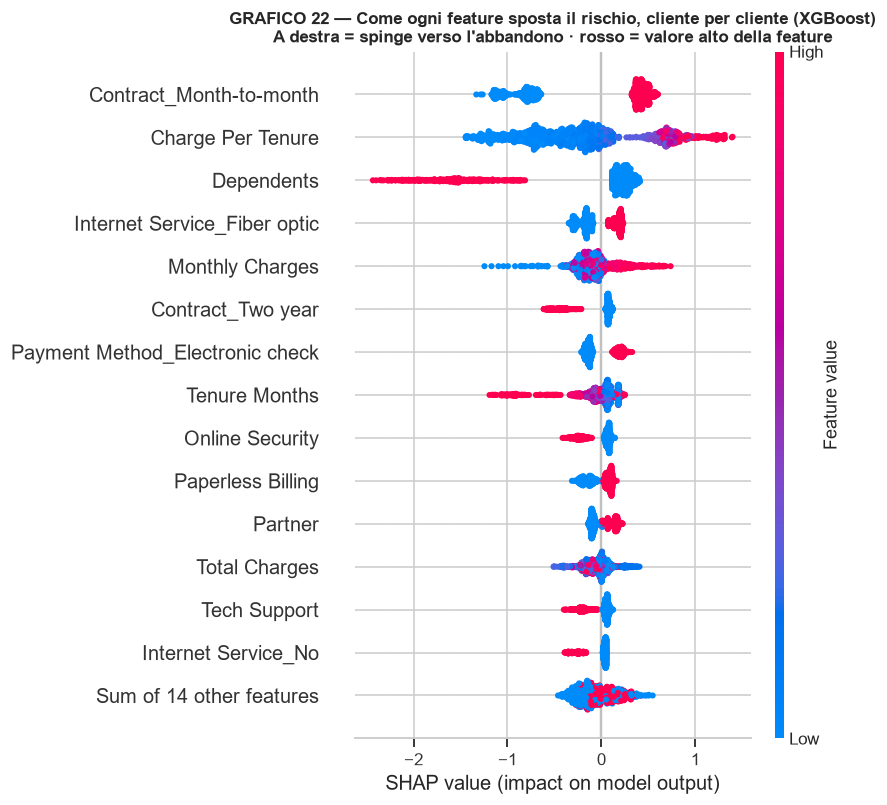

In [53]:
# GRAFICO 22 — Beeswarm SHAP: ogni punto è un cliente del test set
plt.figure(figsize=(9, 7))
shap.plots.beeswarm(shap_xgb, max_display=15, show=False)
plt.title("GRAFICO 22 — Come ogni feature sposta il rischio, cliente per cliente (XGBoost)\n"
          "A destra = spinge verso l'abbandono · rosso = valore alto della feature",
          fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

Il beeswarm dice più di una classifica. Ogni punto è un cliente; la posizione orizzontale è il contributo di quella feature alla *sua* predizione, il colore è il valore della feature per quel cliente.

Si legge così: `Contract_Month-to-month` ha i punti rossi (valore 1, contratto mensile) tutti a destra e i blu (valore 0) a sinistra — nel modello, il contratto mensile dà un contributo positivo al punteggio. Le feature con una nuvola compatta attorno allo zero contribuiscono poco al punteggio. Dove i punti rossi stanno su entrambi i lati, il contributo cambia a seconda della riga: è un segnale di interazione nel modello, non la dimostrazione di un effetto causale.

Top 10 secondo la LOGISTICA (per |coef| normalizzato):
                              rank_log  imp_log  rank_xgb  imp_xgb
Dependents                           1    0.142         3    0.154
Contract_Two year                    2    0.084         6    0.047
Internet Service_No                  3    0.082        14    0.025
Tenure Months                        4    0.072         8    0.041
Internet Service_Fiber optic         5    0.065         4    0.052
Contract_Month-to-month              6    0.063         1    0.176
Online Security                      7    0.037         9    0.033
Phone Service                        8    0.036        16    0.016
Total Charges                        9    0.036        12    0.028
Charge Per Tenure                   10    0.034         2    0.156

Top 10 secondo XGBOOST (per SHAP medio assoluto):
                                 rank_log  imp_log  rank_xgb  imp_xgb
Contract_Month-to-month                 6    0.063         1    0.176
Charge Per Tenure

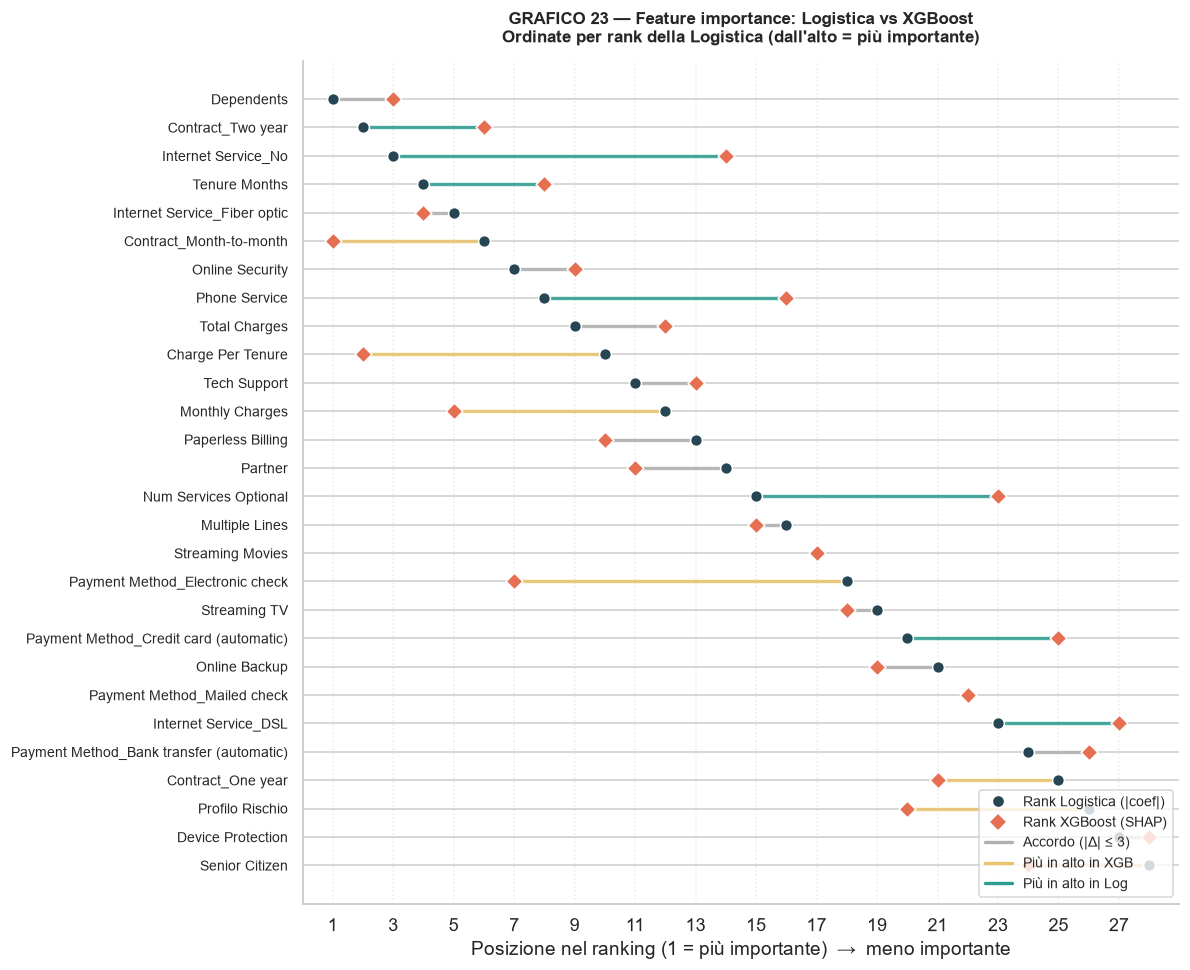

In [54]:
# GRAFICO 23 — Dove ciascuna feature si posiziona nei due modelli (dumbbell chart)
# Ogni riga = una feature. Due punti sulla riga = rank in Logistica e in XGBoost.
# La linea che li collega ha colore in base all'entità del disaccordo.

# Ranking |coef| della logistica, normalizzato a somma 1 per confronto visivo
imp_log = coef.abs()
imp_log = imp_log / imp_log.sum()

confronto = pd.DataFrame({
    "rank_log": imp_log.rank(ascending=False).astype(int),
    "imp_log": imp_log,
    "rank_xgb": imp_shap.rank(ascending=False).astype(int),
    "imp_xgb": imp_shap,
})

print("Top 10 secondo la LOGISTICA (per |coef| normalizzato):")
print(confronto.sort_values("rank_log").head(10).round(3).to_string())
print("\nTop 10 secondo XGBOOST (per SHAP medio assoluto):")
print(confronto.sort_values("rank_xgb").head(10).round(3).to_string())

confronto_plot = confronto.sort_values("rank_log").copy()
confronto_plot["delta_rank"] = confronto_plot["rank_log"] - confronto_plot["rank_xgb"]

fig, ax = plt.subplots(figsize=(11, 9))

# Colori: grigio se le due posizioni sono vicine (|Δ| ≤ 3),
# verde (accento) se la feature è più in alto in XGB (delta > 0),
# giallo (neutro) se più in alto in Log (delta < 0).
for i, (feat, row) in enumerate(confronto_plot.iterrows()):
    delta = row["delta_rank"]
    if abs(delta) <= 3:
        colore = "#B0B0B0"
    elif delta > 0:
        colore = COLOR_ACCENTO
    else:
        colore = COLOR_NEUTRO

    y = i  # riga i-esima (posizione verticale)
    ax.plot([row["rank_log"], row["rank_xgb"]], [y, y],
            color=colore, linewidth=2.2, alpha=0.85, zorder=1)
    ax.scatter(row["rank_log"], y, color="#264653", s=60,
               marker="o", zorder=3, edgecolor="white", linewidth=1)
    ax.scatter(row["rank_xgb"], y, color="#E76F51", s=60,
               marker="D", zorder=3, edgecolor="white", linewidth=1)

ax.set_yticks(range(len(confronto_plot)))
ax.set_yticklabels(confronto_plot.index, fontsize=9)
ax.invert_yaxis()  # feature più importante per Log in alto

ax.set_xlabel("Posizione nel ranking (1 = più importante)  →  meno importante")
ax.set_xlim(0, len(confronto_plot) + 1)
ax.set_xticks(range(1, len(confronto_plot) + 1, 2))
ax.grid(axis="x", linestyle=":", alpha=0.4)

from matplotlib.lines import Line2D
legenda = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor="#264653", markersize=8, label="Rank Logistica (|coef|)"),
    Line2D([0], [0], marker="D", color="w",
           markerfacecolor="#E76F51", markersize=8, label="Rank XGBoost (SHAP)"),
    Line2D([0], [0], color="#B0B0B0", linewidth=2.2, label="Accordo (|Δ| ≤ 3)"),
    Line2D([0], [0], color=COLOR_ACCENTO, linewidth=2.2, label="Più in alto in XGB"),
    Line2D([0], [0], color=COLOR_NEUTRO, linewidth=2.2, label="Più in alto in Log"),
]
ax.legend(handles=legenda, loc="lower right", frameon=True, fontsize=9)

ax.set_title("GRAFICO 23 — Feature importance: Logistica vs XGBoost\n"
             "Ordinate per rank della Logistica (dall'alto = più importante)",
             fontsize=11, weight="bold", pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretazione — le due storie coincidono sulle famiglie, divergono su come impacchettano il segnale.**

Le famiglie di driver sono simili nei due modelli: contratto, tipo di connessione, familiari a carico, spesa rapportata all'anzianità. La concordanza offre una verifica di robustezza interna sul medesimo campione, ma non dimostra che le relazioni siano reali, causali o generalizzabili ad altri periodi e operatori.

Dove divergono, il motivo è quasi sempre lo stesso: **la Logistica distribuisce su più feature un segnale che XGBoost concentra in una sola.**

- **`Charge Per Tenure`** — rank 10 nella Logistica, rank 2 in XGBoost. La feature contiene già l'interazione "spesa alta su pochi mesi", e un albero può sfruttarla con un singolo taglio. Il modello lineare quello stesso segnale se lo ricostruisce sommando `Tenure Months`, `Total Charges` e `Monthly Charges` separatamente: nessuna delle tre risulta dominante presa da sola.
- **`Monthly Charges`** (12 vs 5) e **`Payment Method_Electronic check`** (18 vs 7) — stessa dinamica: XGBoost le usa dentro interazioni con altre variabili, la Logistica può solo assegnare loro un peso medio valido per tutti.
- **`Internet Service_No`** (3 vs 14) e **`Phone Service`** (8 vs 16) vanno nella direzione opposta: identificano il segmento "solo telefono", che nel campione mostra churn basso. La Logistica rappresenta questa associazione con coefficienti negativi; XGBoost isola lo stesso gruppo con due o tre split.

**Una nota su `Profilo Rischio`.** Il flag composito sta al rank 26 nella Logistica e al rank 20 in XGBoost: entrambi i modelli lo considerano marginale. Ha senso — la Logistica somma già linearmente i suoi tre componenti (mensile, fibra, assegno elettronico), e XGBoost le interazioni tra quei tre le ricostruisce da sé. Il flag resta utile come **segmento descrittivo** da sottoporre a valutazione umana, anche se al modello aggiunge poco.

Vale la pena sottolinearlo perché è il punto in cui lo strumento di misura cambia la conclusione: con la feature importance "gain" quel flag risulta rank 3, e la lettura isolata sarebbe "XGBoost sfrutta il flag molto più della Logistica". È soprattutto un effetto del criterio di misura, non una prova di rilevanza operativa.

**Verdetto:** i due modelli convergono su alcune famiglie di segnali e divergono su come le rappresentano. Questa convergenza sostiene la stabilità interna della lettura, ma non sostituisce una validazione esterna o temporale.

## Lettura locale: quali caratteristiche spostano *questo* punteggio

Fin qui ho guardato il modello dall'alto: quali feature contano in media. In una simulazione di revisione umana, davanti a un cliente segnalato la domanda utile è un'altra: *quali caratteristiche hanno spostato il punteggio del modello?* Questa spiegazione riguarda il punteggio, non la causa dell'eventuale abbandono.

SHAP risponde anche a questa, perché i contributi si calcolano per singola predizione. Lo faccio sul modello selezionato per l'artefatto di inferenza del prototipo, la Logistica.

Per un modello lineare vale una semplificazione utile: il valore SHAP della feature *i* per un cliente è esattamente `coefficiente_i × (valore_i − media_i sul training)`. Nessuna approssimazione, è una formula chiusa. La conseguenza pratica è che **l'inferenza del prototipo non richiede la libreria `shap` per calcolare questi contributi**: bastano i coefficienti e le medie del training, che sono già dentro la pipeline. Verifico numericamente l'identità contro la libreria.

In [55]:
# SHAP per la Logistica scelta.
# Il masker va costruito a mano: per default shap campiona 100 righe di
# background, e con una media approssimata i valori non tornerebbero esatti.
sfondo = shap.maskers.Independent(X_train_proc, max_samples=len(X_train_proc))
explainer_log = shap.LinearExplainer(logreg.named_steps["clf"], sfondo)
shap_log = explainer_log(X_test_proc)

# La stessa quantità calcolata a mano: coef × (valore del cliente − media del training)
contributi_manuali = (X_test_proc - X_train_proc.mean()) * coef

differenza = np.abs(shap_log.values - contributi_manuali.values).max()
print(f"Max differenza tra i valori SHAP e coef×(x−media): {differenza:.2e}")
print(f"Le due strade coincidono: {differenza < 1e-10}")

# Controllo della proprietà che rende SHAP affidabile:
# base + somma dei contributi = logit della predizione del modello
i_cliente = int(np.argmax(proba_logreg))          # il cliente più a rischio del test
logit_ricostruito = shap_log.base_values[i_cliente] + shap_log.values[i_cliente].sum()
proba_ricostruita = 1 / (1 + np.exp(-logit_ricostruito))

print(f"\nCliente più a rischio del test (indice {X_test_proc.index[i_cliente]}):")
print(f"  probabilità dal modello      : {proba_logreg[i_cliente]:.4f}")
print(f"  probabilità dai contributi   : {proba_ricostruita:.4f}")

Max differenza tra i valori SHAP e coef×(x−media): 0.00e+00
Le due strade coincidono: True

Cliente più a rischio del test (indice 886):
  probabilità dal modello      : 0.9872
  probabilità dai contributi   : 0.9872


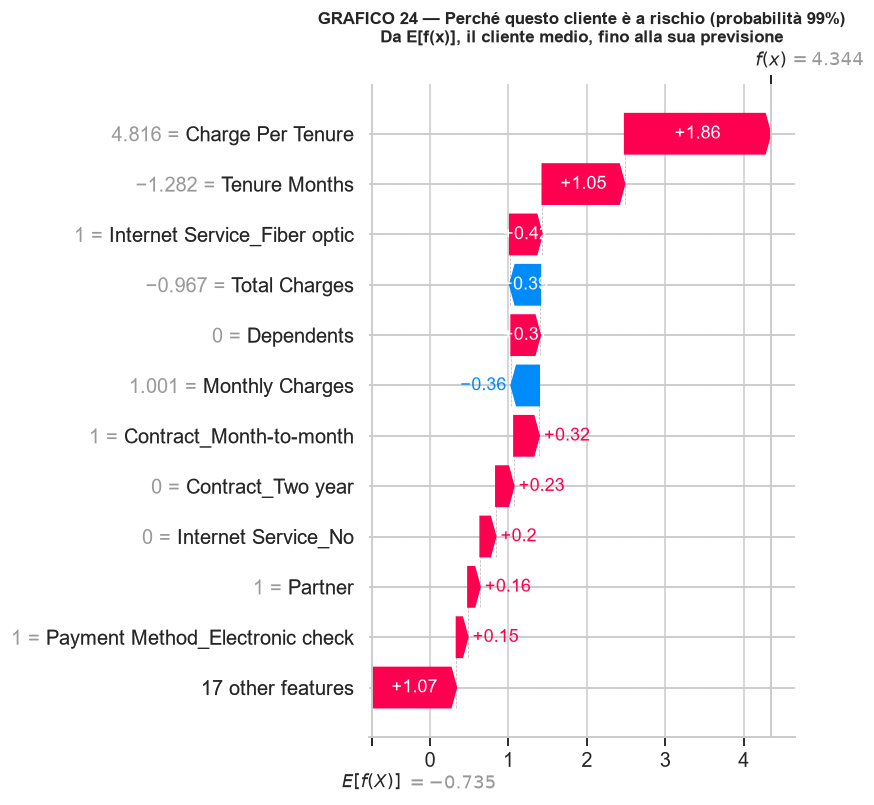

In [56]:
# GRAFICO 24 — Waterfall SHAP del cliente più a rischio del test set
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_log[i_cliente], max_display=12, show=False)
plt.title(f"GRAFICO 24 — Perché questo cliente è a rischio "
          f"(probabilità {proba_logreg[i_cliente]:.0%})\n"
          "Da E[f(x)], il cliente medio, fino alla sua previsione",
          fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

Il waterfall si legge dal basso verso l'alto. Si parte da `E[f(X)] = −0.735`, il log-odds del cliente medio del training, e ogni barra sposta il valore fino alla previsione finale di questo cliente, `f(x) = 4.344`, che corrisponde al 99% di probabilità stimata dal modello. Le barre rosse alzano il punteggio, le blu lo abbassano.

La storia del cliente 886 è leggibile in tre righe: una spesa mensile molto alta rispetto alla sua anzianità (+1.86), pochissimi mesi di permanenza (+1.05), la fibra (+0.42).

C'è anche un dettaglio che merita attenzione: `Monthly Charges` contribuisce **in negativo** (−0.36), cioè abbassa il punteggio per questa riga. Non è una contraddizione con la barra più alta: `Charge Per Tenure` dà un contributo positivo perché combina spesa e breve anzianità, mentre `Monthly Charges`, a parità delle altre feature, dà un contributo negativo. Sono proprietà della funzione appresa, non effetti protettivi o causali sul cliente.

Il confronto mostra la differenza tra un solo punteggio e una descrizione dei fattori che hanno spostato quel punteggio. I contributi non identificano però l'offerta efficace né la leva causale su cui agire: possono soltanto generare ipotesi di intervento da sottoporre a verifica, revisione umana ed eventualmente esperimenti controllati. In 5.7 li raggruppo quindi in tre profili descrittivi, non in prescrizioni commerciali.

In Fase 6 la descrizione dei contributi entra nell'output tecnico della funzione di inferenza, accanto a ogni punteggio.

## Chiusura delle verifiche in sospeso

Chiudo qui le quattro verifiche lasciate aperte nelle fasi precedenti.

### `Gender` esclusa correttamente?

`Gender` è esclusa come input diretto, quindi non entra esplicitamente nelle previsioni; eventuali proxy indiretti e disparità tra sottogruppi non sono stati valutati. Questa esclusione non equivale a una verifica di fairness.

### `Partner` porta segnale oltre `Tenure Months` e `Dependents`?

In EDA `Partner=1` era associato a un churn osservato inferiore (19,7% vs 33,0%), ma nel modello ha coefficiente **positivo** (+0,30). Verifico l'associazione incrociando con `Dependents`.

In [57]:
# Correlazione di Partner con Tenure Months e Dependents (sul train)
print("Correlazioni con Partner (train):")
print(f"  Partner ↔ Tenure Months : {X_train_proc[['Partner','Tenure Months']].corr().iloc[0,1]:+.3f}")
print(f"  Partner ↔ Dependents    : {X_train_proc[['Partner','Dependents']].corr().iloc[0,1]:+.3f}")

# Churn stratificato: Partner condizionatamente a Dependents
tmp = X_train_proc.copy()
tmp["y"] = y_train.values
strat = tmp.groupby(["Dependents", "Partner"])["y"].agg(["mean", "size"])
strat.columns = ["churn_rate", "n"]
print("\nChurn condizionatamente a Dependents × Partner:")
print(strat.round(3))

Correlazioni con Partner (train):
  Partner ↔ Tenure Months : +0.374
  Partner ↔ Dependents    : +0.364

Churn condizionatamente a Dependents × Partner:
                    churn_rate     n
Dependents Partner                  
0          0             0.344  2666
           1             0.300  1667
1          0             0.151   239
           1             0.040  1062


**Cosa dice la tabella:** condizionando su `Dependents`, l'effetto di `Partner` cambia molto —
- senza dipendenti: differenza osservata di 4,4 punti percentuali
- con dipendenti: differenza osservata di 11,1 punti percentuali

Nel campione e nel modello, `Dependents` assorbe parte dell'associazione che altrimenti verrebbe attribuita a `Partner`. Il coefficiente positivo residuo di `Partner` non è un bug: è una relazione condizionata alle altre feature incluse. Il dataset non misura la stabilità familiare e questa analisi non dimostra protezione causale o maggiore mobilità.

**Lettura limitata ai dati osservati:** a parità delle altre feature del modello, le associazioni di `Partner` e `Dependents` cambiano quando vengono considerate insieme. Non è possibile trasformarle in un giudizio sulla situazione familiare della persona o in una leva di retention già validata.

### `Profilo Rischio` porta segnale oltre ai suoi tre componenti?

Coefficiente −0.124 (penultimo in Logistica) e rank 20 per SHAP in XGBoost (rank 3 per gain medio) — la differenza tra le due misure è discussa in 5.3. Per la Logistica è poco utile da sola, perché è ridondante con i tre componenti. Il flag resta soltanto un segmento descrittivo da valutare con revisione umana; non è una regola operativa.

In [58]:
# Test: dentro il gruppo "Profilo Rischio = 1", quanto è alto il churn effettivo?
# E dentro il modello, dei clienti del profilo, quanti vengono flaggati dalla soglia ottima?

# Il flag è una delle 28 feature in uscita dal preprocessore
# Nota: le feature numeriche sono scalate; Profilo Rischio è 0/1 e non è stato scalato
mask_profilo = X_test_proc["Profilo Rischio"] == 1
n_profilo = mask_profilo.sum()

churn_profilo = y_test[mask_profilo].mean()
churn_altri = y_test[~mask_profilo].mean()

# Quanti clienti del profilo vengono correttamente flaggati dal modello alla soglia ottima?
tp_profilo = ((pred_logreg_opt == 1) & mask_profilo & (y_test == 1)).sum()
churner_profilo = (mask_profilo & (y_test == 1)).sum()
flag_profilo = ((pred_logreg_opt == 1) & mask_profilo).sum()

print(f"Sul test: {n_profilo} clienti con Profilo Rischio = 1 ({n_profilo/len(y_test):.1%} della base)")
print(f"  Churn rate nel profilo         : {churn_profilo:.1%}")
print(f"  Churn rate fuori dal profilo   : {churn_altri:.1%}")
print(f"  Modello flagga (soglia {t_logreg:.3f}): {flag_profilo}/{n_profilo} = {flag_profilo/n_profilo:.1%} del profilo")
print(f"  Recall del modello sui churner del profilo: {tp_profilo}/{churner_profilo} = {tp_profilo/churner_profilo:.1%}")

Sul test: 255 clienti con Profilo Rischio = 1 (18.1% della base)
  Churn rate nel profilo         : 58.0%
  Churn rate fuori dal profilo   : 19.6%
  Modello flagga (soglia 0.426): 245/255 = 96.1% del profilo
  Recall del modello sui churner del profilo: 145/148 = 98.0%


Sul test, chi rientra in `Profilo Rischio` ha ancora un tasso di churn molto alto, e il modello ne intercetta oltre il 95% (recall alto in quel segmento). La feature non è inutile, è ridondante *per la Logistica* — il suo contributo è già coperto dai tre componenti.

### `Charge Per Tenure` guadagna importanza rispetto ai suoi componenti?

Coefficiente +0.39 (rank 10) — più alto in valore assoluto di `Monthly Charges` (−0.36) ma non di `Total Charges` (+0.41) o `Tenure Months` (−0.82).

In [59]:
# Correlazioni tra le feature "spesa/anzianità" (sul train)
spesa_feat = ["Tenure Months", "Monthly Charges", "Total Charges", "Charge Per Tenure"]
print("Matrice di correlazione tra feature spesa/anzianità (train):")
print(X_train_proc[spesa_feat].corr().round(2))

print("\nCoefficienti Logistica per queste feature:")
for f in spesa_feat:
    print(f"  {f:<25s}  {coef[f]:+.3f}")

Matrice di correlazione tra feature spesa/anzianità (train):
                   Tenure Months  Monthly Charges  Total Charges  \
Tenure Months               1.00             0.26           0.83   
Monthly Charges             0.26             1.00           0.65   
Total Charges               0.83             0.65           1.00   
Charge Per Tenure          -0.59             0.09          -0.43   

                   Charge Per Tenure  
Tenure Months                  -0.59  
Monthly Charges                 0.09  
Total Charges                  -0.43  
Charge Per Tenure               1.00  

Coefficienti Logistica per queste feature:
  Tenure Months              -0.820
  Monthly Charges            -0.359
  Total Charges              +0.405
  Charge Per Tenure          +0.387


**Cosa emerge:** le quattro feature spesa/anzianità sono fortemente correlate tra loro. Il modello lineare le "contrappone" invece di sovrapporle: `Tenure Months` ha contributo negativo, `Total Charges` positivo, `Monthly Charges` negativo (controintuitivo, tipico con feature correlate), `Charge Per Tenure` positivo.

Il segnale netto resta coerente con l'EDA: cliente nuovo + spesa alta = rischio. `Charge Per Tenure` non domina da sola ma partecipa utilmente a esprimere quel pattern.

*Nota:* in una futura versione varrebbe la pena ridurre la ridondanza tra `Monthly Charges` e `Total Charges`; non lo faccio ora perché il modello è già scelto.

## Perché Logistica ≈ XGBoost? Uno sguardo alla calibrazione

La feature importance (5.3) ha già mostrato che le due storie coincidono. Un secondo confronto è la **calibrazione**: se il modello dice "70% di probabilità di churn", quel 70% dovrebbe corrispondere alla frequenza osservata. Un modello con buon ranking ma cattiva calibrazione produce probabilità inaffidabili come stime di rischio assoluto.

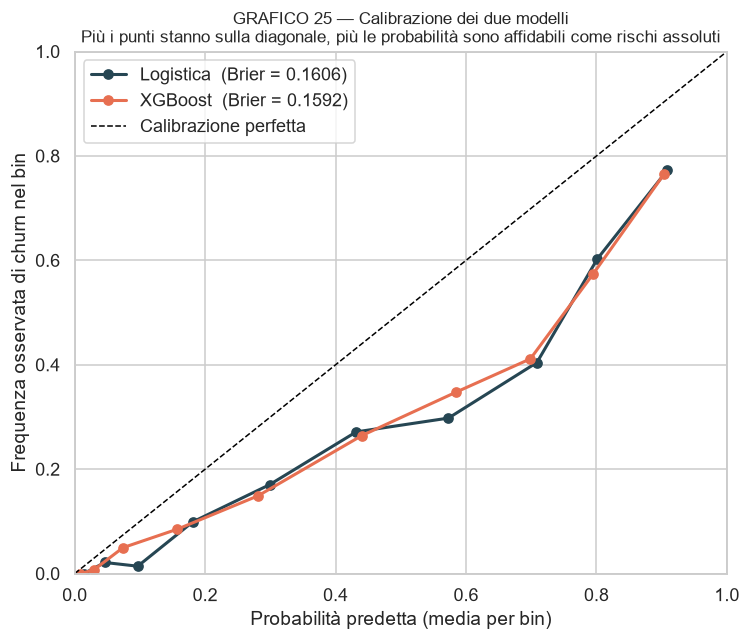

In [60]:
# GRAFICO 25 — Calibration plot dei due modelli
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(7, 6))

for nome, proba, colore in [
    ("Logistica", proba_logreg, PALETTE_CHURN["Resta (No)"]),
    ("XGBoost", proba_xgb, PALETTE_CHURN["Abbandona (Yes)"]),
]:
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    brier = brier_score_loss(y_test, proba)
    ax.plot(prob_pred, prob_true, marker="o", color=colore,
            label=f"{nome}  (Brier = {brier:.4f})", linewidth=2)

# Diagonale = calibrazione perfetta
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Calibrazione perfetta")

ax.set_xlabel("Probabilità predetta (media per bin)")
ax.set_ylabel("Frequenza osservata di churn nel bin")
ax.set_title("GRAFICO 25 — Calibrazione dei due modelli\n"
             "Più i punti stanno sulla diagonale, più le probabilità sono affidabili come rischi assoluti",
             fontsize=11)
ax.legend(loc="upper left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Lettura:** i Brier score e il grafico a dieci bin descrivono una calibrazione simile sul test, ma non dimostrano che ogni probabilità individuale sia un rischio assoluto affidabile. `class_weight='balanced'` è stato scelto per il trade-off di classificazione e può alterare la calibrazione.

La simulazione usa il ranking osservato nel holdout, ma non dimostra che il ranking resti stabile su periodi o operatori diversi. Per un eventuale uso delle probabilità o dell'ordinamento servirebbero dati separati, verifica temporale e monitoraggio. La vicinanza Logistica-XGBoost resta un risultato interno a questo campione.

## Analisi descrittiva del ranking e ipotesi da validare

Questa sezione mostra come leggere volume, decili e profili in una simulazione sul holdout. Non fornisce regole d'uso o offerte già validate: le associazioni producono ipotesi da sottoporre a verifica causale, controllo di fairness, validazione temporale o esterna e revisione umana. Il prototipo non è pronto per un uso operativo o commerciale.

Sul test finale di 1.409 clienti, la soglia OOF 0,426 segnala 639 clienti, pari al 45,4% della base. Intercetta l'83,7% dei churner con precisione 49,0%: 61 falsi negativi e 326 falsi positivi, per un costo osservato di 631 unità al rapporto 5:1.

La soglia non è stata abbassata dopo aver visto questi risultati. Il trade-off è quindi una stima finale onesta della regola selezionata sul training, non il minimo retrospettivo del test.

In [61]:
# Conteggi descrittivi sul solo holdout
n_test = len(y_test)
n_flag = int(pred_logreg_opt.sum())
tp = int(((pred_logreg_opt == 1) & (y_test == 1)).sum())
fp = int(((pred_logreg_opt == 1) & (y_test == 0)).sum())
fn = int(((pred_logreg_opt == 0) & (y_test == 1)).sum())

print("Conteggi descrittivi sul solo holdout:")
print(f"  Osservazioni totali        : {n_test:,}")
print(f"  Predizioni sopra soglia    : {n_flag:,} ({n_flag/n_test:.1%} del campione)")
print(f"    - Veri positivi          : {tp:,}")
print(f"    - Falsi positivi         : {fp:,}")
print(f"  Falsi negativi             : {fn:,}")

Conteggi descrittivi sul solo holdout:
  Osservazioni totali        : 1,409
  Predizioni sopra soglia    : 639 (45.4% del campione)
    - Veri positivi          : 313
    - Falsi positivi         : 326
  Falsi negativi             : 61


Nel solo holdout, la soglia produce 639 predizioni positive su 1.409 osservazioni (45,4%), con recall 83,7% e precisione 49,0%; il costo di 631 unità deriva dallo scenario ipotetico 5:1 discusso in Fase 4. Questi risultati descrivono il campione, ma non stabiliscono che il volume sia gestibile, che il trade-off sia economicamente conveniente o che resti stabile nel tempo. Prima di qualunque uso servono costi reali, validazione esterna o temporale, controllo di fairness e revisione umana.

### Segmentazione descrittiva per decili del punteggio

Divido le osservazioni del test in 10 decili del punteggio (decile 1 = 10% con punteggio più alto, decile 10 = 10% con punteggio più basso). La tabella descrive concentrazione e ranking nel solo holdout; non stabilisce priorità operative.

In [62]:
# I cut-point di analisi sono stimati sulle probabilità OOF del training,
# non sul test. Il test serve soltanto a misurare il lift ottenuto.
DECILI_RIFERIMENTO_OOF = np.quantile(
    proba_logreg_oof, np.arange(0.1, 1.0, 0.1)
)
assert DECILI_RIFERIMENTO_OOF.shape == (9,)
assert np.all(np.diff(DECILI_RIFERIMENTO_OOF) > 0)

df_dec = pd.DataFrame({"proba": proba_logreg, "y": y_test.values})
df_dec["decile"] = 10 - np.digitize(
    df_dec["proba"], DECILI_RIFERIMENTO_OOF
)

tab = df_dec.groupby("decile", observed=True).agg(
    clienti=("y", "size"),
    churner=("y", "sum"),
    churn_rate=("y", "mean"),
    proba_media=("proba", "mean"),
).sort_index()
tab["churner_cum"] = tab["churner"].cumsum()
tab["copertura_%"] = 100 * tab["churner_cum"] / int(y_test.sum())

print("Cut-point dei decili selezionati sulle predizioni OOF:")
print(np.round(DECILI_RIFERIMENTO_OOF, 4))
print("\nPrestazioni dei decili sul test finale:\n")
print(f"{'Decile':>6}  {'Clienti':>8}  {'Churner':>8}  {'Churn %':>8}  {'Proba media':>12}  {'Copertura cum.':>14}")
print("-" * 68)
for d, row in tab.iterrows():
    print(f"{d:>6}  {int(row['clienti']):>8}  {int(row['churner']):>8}  "
          f"{row['churn_rate']*100:>7.1f}%  {row['proba_media']:>12.3f}  {row['copertura_%']:>13.1f}%")

Cut-point dei decili selezionati sulle predizioni OOF:
[0.0289 0.0694 0.1363 0.2297 0.3628 0.4982 0.6384 0.7555 0.851 ]

Prestazioni dei decili sul test finale:

Decile   Clienti   Churner   Churn %   Proba media  Copertura cum.
--------------------------------------------------------------------
     1       136       108     79.4%         0.911           28.9%
     2       149        87     58.4%         0.802           52.1%
     3       145        56     38.6%         0.704           67.1%
     4       131        41     31.3%         0.571           78.1%
     5       147        40     27.2%         0.431           88.8%
     6       146        25     17.1%         0.293           95.5%
     7       123        12      9.8%         0.181           98.7%
     8       154         2      1.3%         0.098           99.2%
     9       131         2      1.5%         0.046           99.7%
    10       147         1      0.7%         0.015          100.0%


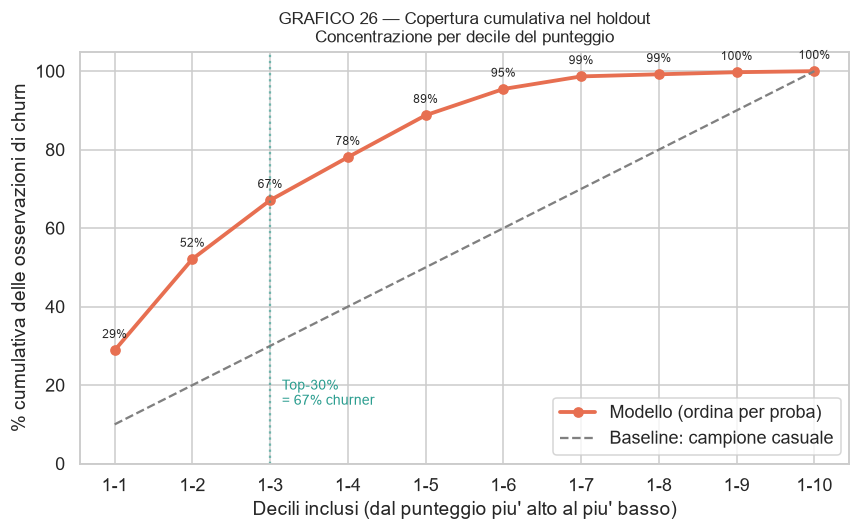

In [63]:
# GRAFICO 26 — Copertura cumulativa del churn osservato per decile del punteggio
fig, ax = plt.subplots(figsize=(8, 5))

# Asse x: quanti decili top-N del punteggio sono inclusi nell'analisi
# tab e' gia' ordinato con decile 1 in cima
x = list(range(1, 11))
y_cop = tab["copertura_%"].values     # copertura cumulativa dei churner
y_random = [10 * i for i in x]        # baseline: 10% della base scelto a caso cattura il 10% dei churner

ax.plot(x, y_cop, marker="o", color=PALETTE_CHURN["Abbandona (Yes)"], linewidth=2.5,
        label="Modello (ordina per proba)")
ax.plot(x, y_random, linestyle="--", color="gray", linewidth=1.5,
        label="Baseline: campione casuale")

# Evidenzio i tre decili con punteggio piu' alto
ax.axvline(3, color=COLOR_NEUTRO, linestyle=":", alpha=0.6)
ax.text(3.15, 15, f"Top-30%\n= {y_cop[2]:.0f}% churner", fontsize=9, color=COLOR_NEUTRO)

for xi, yi in zip(x, y_cop):
    ax.annotate(f"{yi:.0f}%", (xi, yi), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

ax.set_xlabel("Decili inclusi (dal punteggio piu' alto al piu' basso)")
ax.set_ylabel("% cumulativa delle osservazioni di churn")
ax.set_title("GRAFICO 26 — Copertura cumulativa nel holdout\n"
             "Concentrazione per decile del punteggio", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([f"1-{i}" for i in x])
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

**Lettura statistica limitata al holdout:**
- il **top 30%** dei punteggi contiene circa il **67%** delle osservazioni di churn
- il **top 50%** contiene circa l'**89%** delle osservazioni di churn
- il **bottom 20%** contiene meno del 2% delle osservazioni di churn nel holdout; il dato non giustifica l'esclusione di clienti futuri

Il churn rate del decile 1 (79,4%) è circa 3 volte la media del test (26,5%). Il risultato mostra una forte concentrazione del rischio nel solo holdout casuale, ma non garantisce prestazioni operative future: servono revisione umana e validazione esterna o temporale.

### Tre profili descrittivi — ipotesi da testare

Raggruppo i contributi della Logistica in tre profili ricorrenti. Le proposte associate sono ipotesi sperimentali, non raccomandazioni: i coefficienti descrivono il modello e non dimostrano che una determinata offerta riduca il churn.

**A — Nuovo cliente in fibra, contratto mensile** (= `Profilo Rischio`, ~60% di churn nel training). *Ipotesi da testare:* confrontare, con criteri di eleggibilità e controllo, proposte come contratto annuale, servizio complementare o pagamento automatico.

**B — Spesa alta, pochi servizi complementari.** *Ipotesi da testare:* valutare se un servizio complementare modifica davvero la retention; il modello non dimostra che aumentare i servizi causi una riduzione del churn.

**C — Nessun familiare a carico registrato** (`Dependents=0`). *Ipotesi da testare:* confrontare leve di engagement e di prezzo senza presumere che questa variabile rappresenti un legame causale o una condizione personale stabile.

I tre profili non sono esclusivi e non decidono chi contattare o cosa offrire. Servono a formulare domande verificabili; qualunque intervento richiede valutazione umana, governance e una misura sperimentale degli effetti.

## Validità nel tempo — cosa può rendere il modello obsoleto

Il modello è addestrato su una "fotografia" dei clienti che cattura condizioni specifiche (contratti, prezzi, concorrenza) destinate a cambiare. Un eventuale uso richiederebbe criteri di monitoraggio e di riesame definiti su dati futuri. Elenco scenari plausibili di degrado senza assegnare probabilità non misurate.

### Scenari di obsolescenza

1. **Cambio catalogo/prezzi** — un nuovo piano potrebbe modificare l'associazione osservata tra fibra e churn.
2. **Mosse della concorrenza** — potrebbero modificare sia i tassi base sia l'ordinamento; nessuno dei due è garantito.
3. **Cambiamenti demografici/economici** — potrebbero spostare il mix delle feature e le relazioni apprese.
4. **Cambio del processo commerciale** — potrebbe cambiare la distribuzione degli input e il volume sopra soglia.
5. **Interventi di retention** — se applicati, modificherebbero i dati osservati e richiederebbero una strategia causale per distinguere effetto dell'intervento e drift.

### Esempio di piano di monitoraggio da definire prima dell'uso

Le cadenze e le soglie seguenti sono illustrative e andrebbero concordate su volumi, costi e ritardi reali.

**Settimanale:** distribuzione dei punteggi; percentuale di clienti sopra soglia.

**Mensile:** churn rate osservato per decile; calibrazione; precision/recall sulla soglia scelta (con ritardo).

**Trimestrale:** ri-valutazione della soglia se cambiano i costi; controllo del drift delle feature core rispetto al training.

**Semestrale:** ri-addestramento completo (attenzione allo scenario 5); sostituire il modello solo se il nuovo è chiaramente e stabilmente migliore.

### Esempi di segnali da valutare

Prima di un eventuale uso, soglie e procedure di monitoraggio andrebbero calibrate su dati e vincoli reali. A puro titolo illustrativo, variazioni di 5 punti percentuali in precision, recall o churn rate, cambi di catalogo o spostamenti misurabili nelle feature core potrebbero avviare un'analisi. Non sono trigger operativi validati e non implicano automaticamente un ri-addestramento.

## Sintesi Fase 5 — cosa consegno alla Fase 6

**Modello e selezione:** Logistica scelta con regola one-standard-error sul training; soglia 0,426 selezionata sulle probabilità OOF. Il vantaggio di costo di XGBoost è riportato come condizione di riesame, non cancellato.

**Test finale:** ROC-AUC 0,854, PR-AUC 0,675, precision 0,490, recall 0,837; 639 clienti sopra soglia su 1.409.

**Interpretazione:** i contributi locali del modello lineare coincidono con `coefficiente × (valore − media)`. Le associazioni individuano ipotesi da sperimentare, non cause o priorità operative già dimostrate.

**Decili:** i nove cut-point sono calcolati sulle predizioni OOF del training e poi applicati al test. Il decile 1 contiene 136 clienti con churn rate osservato 79,4%; i primi tre decili intercettano il 67,1% dei churner del test.

**Calibrazione:** utile come controllo descrittivo, non sufficiente per interpretare ogni probabilità come rischio assoluto. Per decisioni monetarie servirebbe una calibrazione separata e temporale.

Per la Fase 6 la pipeline deve congelare insieme preprocessing, modello, baseline delle spiegazioni, soglia OOF e cut-point OOF dei decili.

---
# Fase 6 — Confezionamento e inferenza del prototipo

Questa fase confeziona un prototipo riproducibile e non documenta un deployment aziendale reale. Il grosso è già fatto, e non per caso: **il modello scelto in Fase 4 è già una pipeline che parte dai dati grezzi**. Non c'è un preprocessing "del notebook" da riscrivere per l'inferenza, perché fin dalla Fase 2 ne esiste una sola implementazione, quella di `churn_inference.py`, usata sia per addestrare sia per prevedere.

È il punto che distingue un notebook isolato da un prototipo più facile da mantenere. La versione alternativa — preprocessing a mano nel notebook, poi una classe separata per l'inferenza — può divergere quando una delle due copie viene aggiornata. La singola implementazione riduce questo rischio, ma non lo elimina: versioni, configurazione, schema dei dati e ambiente di esecuzione devono comunque essere controllati.

**Cosa resta da fare:** 1) registrare nella pipeline le medie del training, che servono alle spiegazioni locali; 2) serializzarla con `joblib` e verificare che l'oggetto ricaricato dia predizioni identiche; 3) mostrare la funzione di inferenza su singoli clienti e in batch.

## Il modulo `churn_inference.py`

Il modulo che il notebook usa dalla Fase 2 contiene la logica condivisa dal prototipo di addestramento e inferenza. Non rappresenta da solo un sistema di produzione. Contiene:

| Cosa | A che serve |
|---|---|
| costanti di schema | le 18 colonne raw attese, i gruppi di colonne, i cut-point dei decili |
| `ChurnFeatureEngineer` | pulizia e feature engineering |
| `crea_preprocessore()` | feature engineering + scaling + encoding, in un `ColumnTransformer` |
| `predici_churn()` | probabilità, decisione, decile, motivi |
| `contributi_locali()`, `motivi_principali()` | spiegazione della singola predizione |
| `categorie_non_viste()` | diagnostica sui valori categorici nuovi |
| `registra_baseline()` | congela le medie del training dentro la pipeline |

C'è un motivo tecnico per cui la classe deve stare in un file e non nel notebook: `joblib.dump` salva lo *stato* dell'oggetto, non il codice della sua classe. Al `load`, Python deve poter importare `ChurnFeatureEngineer` da qualche parte — se fosse definita solo dentro il notebook, ricaricare la pipeline in uno script o in un job schedulato darebbe errore.

In [64]:
from churn_inference import (
    predici_churn,
    registra_parametri_operativi,
    nomi_feature,
    motivi_principali,
)

print(f"Colonne raw attese in input : {len(COLONNE_RAW_INPUT)}")
print(f"Colonne numeriche scalate   : {len(COLONNE_NUMERICHE)}")
print(f"Cut-point OOF dei decili    : {len(DECILI_RIFERIMENTO_OOF)}")

Colonne raw attese in input : 18
Colonne numeriche scalate   : 5
Cut-point OOF dei decili    : 9


## La pipeline da serializzare

Nessuna ricostruzione: `pipeline_churn` è lo stesso oggetto `logreg` addestrato in Fase 3 e scelto in Fase 4, con i suoi due step (`prep` → `clf`).

L'unica aggiunta è `registra_baseline()`, che calcola e congela dentro la pipeline la media di ogni feature sul training set. Serve alle spiegazioni locali: il contributo di una caratteristica si misura come scostamento dal cliente medio, quindi quel riferimento va salvato insieme al modello — altrimenti una successiva inferenza potrebbe ricalcolarlo su dati diversi e le spiegazioni cambierebbero significato nel tempo.

In [65]:
pipeline_churn = logreg
registra_parametri_operativi(
    pipeline_churn,
    X_train,
    soglia=t_logreg,
    cut_decili=DECILI_RIFERIMENTO_OOF,
)

prep = pipeline_churn.named_steps["prep"]
clf = pipeline_churn.named_steps["clf"]
print(f"Step della pipeline: {[nome for nome, _ in pipeline_churn.steps]}")
print(f"Feature in uscita: {len(nomi_feature(pipeline_churn))}")
print(f"Soglia di decisione congelata: {pipeline_churn.soglia_decisione_:.3f}")
print(f"Cut-point congelati: {np.round(pipeline_churn.decili_riferimento_, 4)}")
print(f"Baseline portabile: {type(pipeline_churn.medie_train_).__name__}")

Step della pipeline: ['prep', 'clf']


Feature in uscita: 28
Soglia di decisione congelata: 0.426
Cut-point congelati: [0.0289 0.0694 0.1363 0.2297 0.3628 0.4982 0.6384 0.7555 0.851 ]
Baseline portabile: ndarray


## Verifica end-to-end

Tre controlli che coprono i modi realistici in cui l'inferenza può divergere dall'addestramento:

1. **Coerenza con la Fase 4** — la pipeline riproduce la confusion matrix alla soglia scelta.
2. **Singolo cliente contro batch** — un cliente valutato da solo deve ottenere esattamente la stessa probabilità che otterrebbe dentro un'estrazione di mille. È il controllo che smaschera un preprocessing dipendente dal contenuto del batch: era il difetto strutturale di `pd.get_dummies()`, che le colonne se le costruiva a partire dai dati della singola chiamata.
3. **Ricarica da disco** — l'oggetto deserializzato dà le stesse predizioni dell'originale.

In [66]:
from sklearn.metrics import confusion_matrix

# 1) Coerenza con la Fase 4
proba_pipeline = pipeline_churn.predict_proba(X_test)[:, 1]
print(f"Max differenza rispetto alle probabilità di Fase 3: "
      f"{np.abs(proba_pipeline - proba_logreg).max():.2e}")

cm_pipeline = confusion_matrix(y_test, (proba_pipeline >= t_logreg).astype(int))
cm_fase4 = confusion_matrix(y_test, pred_logreg_opt)
print(f"Confusion matrix identica a quella di Fase 4: {(cm_pipeline == cm_fase4).all()}")

# 2) Un cliente da solo deve valere quanto lo stesso cliente dentro un batch
singoli = np.array([
    pipeline_churn.predict_proba(X_test.iloc[[i]])[:, 1][0]
    for i in range(25)
])
print(f"\nMax scarto tra valutazione singola e in batch (25 clienti): "
      f"{np.abs(singoli - proba_pipeline[:25]).max():.2e}")

Max differenza rispetto alle probabilità di Fase 3: 0.00e+00
Confusion matrix identica a quella di Fase 4: True



Max scarto tra valutazione singola e in batch (25 clienti): 5.55e-17


## Serializzazione con `joblib`

Salvo su disco e ricarico subito per verificare che l'oggetto ricaricato dia gli stessi risultati.

In [67]:
import joblib

percorso_modello = "pipeline_churn.joblib"
joblib.dump(pipeline_churn, percorso_modello)
print(f"Pipeline salvata in: {percorso_modello}")

pipeline_ricaricata = joblib.load(percorso_modello)
proba_ricaricata = pipeline_ricaricata.predict_proba(X_test)[:, 1]
max_diff_ricarica = np.abs(proba_ricaricata - proba_pipeline).max()
print(f"Max differenza dopo la ricarica: {max_diff_ricarica:.2e}")
print(f"Pipeline ricaricata identica: {max_diff_ricarica < 1e-10}")
print(f"Baseline presente: {hasattr(pipeline_ricaricata, 'medie_train_')}")
print(f"Soglia presente: {hasattr(pipeline_ricaricata, 'soglia_decisione_')}")
print(f"Decili presenti: {hasattr(pipeline_ricaricata, 'decili_riferimento_')}")

Pipeline salvata in: pipeline_churn.joblib
Max differenza dopo la ricarica: 0.00e+00
Pipeline ricaricata identica: True
Baseline presente: True
Soglia presente: True
Decili presenti: True


## La funzione di inferenza `predici_churn`

Firma: `predici_churn(pipeline, clienti, soglia=None, con_motivazioni=False)`. Se la soglia è omessa, la funzione usa quella congelata nell'artefatto. Accetta un DataFrame, un dict, una Series o una lista di dict. Restituisce sempre un DataFrame con:

- **`proba`** — probabilità stimata dal modello, da validare prima di usarla per priorizzare
- **`decisione`** — 0/1 alla soglia scelta
- **`decile`** — 1-10 (1 = più a rischio), calcolato rispetto alla distribuzione OOF di riferimento della Fase 5, non rispetto ai clienti della singola chiamata
- **`motivi`** — se `con_motivazioni=True`, i tre contributi che più alzano il punteggio del modello per quella riga

La soglia selezionata OOF è salvata nel modello; resta sovrascrivibile per analisi di scenario esplicite. E se tra i clienti compare una categoria mai vista in addestramento, la funzione emette un avviso invece di ignorarla in silenzio.

Esempio su due profili sintetici costruiti per ottenere, rispettivamente, un punteggio atteso alto e basso.

In [68]:
profilo_punteggio_alto = {
    "Senior Citizen":    "No",
    "Partner":           "No",
    "Dependents":        "No",
    "Tenure Months":     3,
    "Phone Service":     "Yes",
    "Multiple Lines":    "No",
    "Internet Service":  "Fiber optic",
    "Online Security":   "No",
    "Online Backup":     "No",
    "Device Protection": "No",
    "Tech Support":      "No",
    "Streaming TV":      "Yes",
    "Streaming Movies":  "Yes",
    "Contract":          "Month-to-month",
    "Paperless Billing": "Yes",
    "Payment Method":    "Electronic check",
    "Monthly Charges":   95.50,
    "Total Charges":     286.50,   # ~3 mesi × 95.50
}

profilo_punteggio_basso = {
    "Senior Citizen":    "No",
    "Partner":           "Yes",
    "Dependents":        "Yes",
    "Tenure Months":     60,
    "Phone Service":     "Yes",
    "Multiple Lines":    "Yes",
    "Internet Service":  "DSL",
    "Online Security":   "Yes",
    "Online Backup":     "Yes",
    "Device Protection": "Yes",
    "Tech Support":      "Yes",
    "Streaming TV":      "No",
    "Streaming Movies":  "No",
    "Contract":          "Two year",
    "Paperless Billing": "No",
    "Payment Method":    "Bank transfer (automatic)",
    "Monthly Charges":   65.00,
    "Total Charges":     3900.00,  # ~60 mesi × 65
}

esiti = predici_churn(
    pipeline_ricaricata,
    [profilo_punteggio_alto, profilo_punteggio_basso],
    soglia=t_logreg,
    con_motivazioni=True,
)

print("Esempio di inferenza su due clienti tipo:")
print(esiti[["proba", "decisione", "decile"]].round(3).to_string())

print("\nContributi principali al punteggio del modello:")
for etichetta, riga in zip(["punteggio alto", "punteggio basso"], esiti.itertuples()):
    print(f"  profilo a {etichetta}: {riga.motivi}")


Esempio di inferenza su due clienti tipo:
   proba  decisione  decile
0  0.927          1       1
1  0.008          0      10

Contributi principali al punteggio del modello:
  profilo a punteggio alto: anzianità: sotto la media (+0.98); spesa mensile rapportata all'anzianità: sopra la media (+0.81); connessione in fibra: sì (+0.42)
  profilo a punteggio basso: servizi opzionali attivi: sopra la media (+0.32); spesa totale accumulata: sopra la media (+0.28); nessuna connessione internet: no (+0.20)


Il profilo a punteggio alto riceve il valore atteso dalla costruzione dell'esempio, mentre il profilo a punteggio basso riceve un valore inferiore. Poiché sono profili sintetici senza esito osservato, l'esempio verifica il comportamento tecnico del modello, non la correttezza della classificazione. Il decile usa cut-point fissi stimati sulle probabilità out-of-fold del training: resta quindi confrontabile tra chiamate e batch diversi.

## Inferenza in batch — ispezione dei punteggi

Simulo un possibile flusso di inferenza: arriva un'estrazione mensile, la pipeline restituisce probabilità, decisione, decile e motivi. Uso il test set come sostituto (1.409 clienti), che il modello non ha mai visto in addestramento. Questa simulazione tecnica non valida un processo commerciale reale e non autorizza decisioni automatiche sui clienti.

In [69]:
esiti_batch = predici_churn(
    pipeline_ricaricata,
    X_test,
    soglia=t_logreg,
    con_motivazioni=True,
)

print("Riepilogo dei punteggi su 1.409 osservazioni holdout:")
print(f"- predizioni sopra soglia: {esiti_batch['decisione'].sum():,} "
      f"({esiti_batch['decisione'].mean()*100:.1f}% del totale)")
print(f"- probabilità media dei sopra-soglia:   {esiti_batch.loc[esiti_batch['decisione']==1, 'proba'].mean():.3f}")
print(f"- probabilità media dei sotto-soglia:   {esiti_batch.loc[esiti_batch['decisione']==0, 'proba'].mean():.3f}")

print("\nChurn rate reale per decile (verifica del lift chart di Fase 5):")
churn_per_decile = (esiti_batch.assign(y=y_test.values)
                              .groupby("decile")["y"]
                              .agg(["mean", "count"])
                              .round(3))
churn_per_decile.columns = ["churn_rate", "n_clienti"]
print(churn_per_decile)

print("\nPrime righe ordinate per punteggio (ispezione tecnica):")
print(esiti_batch.sort_values("proba", ascending=False)
                 .head(3)[["proba", "decile", "motivi"]]
                 .to_string())

Riepilogo dei punteggi su 1.409 osservazioni holdout:
- predizioni sopra soglia: 639 (45.4% del totale)
- probabilità media dei sopra-soglia:   0.714
- probabilità media dei sotto-soglia:   0.150

Churn rate reale per decile (verifica del lift chart di Fase 5):
        churn_rate  n_clienti
decile                       
1            0.794        136
2            0.584        149
3            0.386        145
4            0.313        131
5            0.272        147
6            0.171        146
7            0.098        123
8            0.013        154
9            0.015        131
10           0.007        147

Prime righe ordinate per punteggio (ispezione tecnica):
         proba  decile                                                                                                                               motivi
886   0.987179       1  spesa mensile rapportata all'anzianità: sopra la media (+1.86); anzianità: sotto la media (+1.05); connessione in fibra: sì (+0.42)
590   0.9

Il churn rate del decile 1 (79,4% sul test) è circa 3 volte la media, coerente col lift chart della Fase 5. La funzione produce una tabella ordinata per `proba` per l'ispezione tecnica; non costituisce una lista di contatto. Stabilità futura e qualsiasi uso operativo restano da validare.

## Sintesi Fase 6 — deliverable finali

| Cosa | Dove |
|---|---|
| Preprocessing, validazione dello schema e spiegazioni locali | `churn_inference.py` |
| Pipeline addestrata | `pipeline_churn.joblib` |
| Soglia e cut-point OOF | attributi della pipeline serializzata |
| Ambiente di inferenza verificato | `requirements-lock.txt` |

**Coerenza verificata:** la pipeline serializzata riproduce le probabilità del test, mantiene invariata la previsione tra singolo cliente e batch e conserva baseline, soglia e decili dopo la ricarica.

```python
import joblib
import pandas as pd
from churn_inference import predici_churn

pipeline = joblib.load("pipeline_churn.joblib")
clienti_attivi = pd.read_csv("clienti_attivi.csv")
esiti = predici_churn(pipeline, clienti_attivi, con_motivazioni=True)
esiti.sort_values("proba", ascending=False).to_csv("punteggi_churn.csv")
```

La soglia di decisione selezionata OOF arriva dall'artefatto. Una soglia passata esplicitamente rappresenta una simulazione di scenario e va documentata. Restano attività future: validazione su dati temporali nuovi, calibrazione dedicata se servono probabilità assolute, monitoraggio del drift e confronto economico con XGBoost usando costi aziendali reali.